In [56]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn


# Predicción del Precio de Laptops mediante Regresión Lineal


**Tipo de proyecto:** Regresión supervisada (aprendizaje automático)
**Stack:** Python · pandas · seaborn · scikit-learn · XGBoost - Claude (Busqueda especifica de componentes y automatizacion con defs para los componentes)

---

### Resumen del proyecto

Este notebook documenta, de principio a fin, la construcción de un modelo de regresión para
predecir el precio de una laptop a partir de sus especificaciones técnicas (procesador, RAM,
almacenamiento, GPU, pantalla, sistema operativo, etc.).

El objetivo no es solo entrenar un modelo, sino mostrar el proceso completo de un proyecto de
ciencia de datos: entender el problema de negocio,el cual implica conocimiento técnico de hardware en
variables útiles, limpiar y transformar los datos con criterio estadístico, entrenar un modelo
interpretable (regresión lineal) y, finalmente, contrastarlo contra modelos más flexibles
(Random Forest, XGBoost) para cuantificar cuánta precisión se gana o se pierde al elegir
interpretabilidad.

## 1. Problema de negocio

El mercado de laptops ofrece cientos de combinaciones de marca, procesador, RAM, almacenamiento
y tarjeta gráfica, y el precio de cada configuración no siempre es transparente ni consistente
entre marcas.

Donde por temas de IA, componentes escasos y nuevas tecnologias, se tiene que tomar decisiones precisas donde se 
busca, 

1. Los mejores componentes
2. Un presupuesto el cual mayormente es limitado 

Simplemente una teoria de bienes y servicios

**¿Por qué importa predecir el precio a partir de las especificaciones?**

- **Para un retailer o e-commerce:** permite fijar precios competitivos para un nuevo modelo
  antes de tener historial de ventas, o detectar productos mal cotizados (muy por encima o muy
  por debajo de lo que sus specs justifican).
- **Para un consumidor:** ayuda a responder "¿esta laptop está bien cotizada para lo que trae?".
- **Para un analista de producto:** identifica qué componentes (RAM, GPU, procesador, marca)
  explican mejor las diferencias de precio en el mercado.

**Objetivo del proyecto:** construir un modelo que prediga el precio (en USD) de una laptop a
partir de sus características técnicas. Se prioriza primero la **interpretabilidad** (regresión
lineal, poder explicar *por qué* predice ese precio) y luego se evalúa si vale la pena sacrificar
esa interpretabilidad a cambio de más precisión (Random Forest / XGBoost).

**Variable respuesta (target):** `price` (precio de la laptop, convertido de rupias indias a
dólares; luego transformado a `price_log`).

**Variables predictoras candidatas:** marca, procesador (marca y núcleos), RAM, almacenamiento,
GPU (marca y rendimiento estimado en TFLOPS), tamaño y resolución de pantalla, sistema operativo.

## 2. Entendimiento de los datos y las variables

El dataset original contiene una fila por modelo de laptop, con las siguientes columnas crudas:

| Columna | Descripción | Tipo original |
|---|---|---|
| `name` | Nombre comercial completo del modelo | texto libre (se descarta: es un identificador) |
| `brand` | Marca del fabricante (Dell, HP, Lenovo, etc.) | categórica |
| `processor` | Descripción textual del procesador | texto libre |
| `CPU` | Descripción de núcleos/hilos del procesador | texto libre |
| `Ram` | Capacidad de RAM | texto ("8GB", "16GB", ...) |
| `Ram_type` | Tecnología de RAM (DDR4, LPDDR5, etc.) | categórica |
| `ROM` | Capacidad de almacenamiento | texto ("512GB", "1TB", ...) |
| `GPU` | Descripción textual de la tarjeta gráfica | texto libre |
| `display_size` | Tamaño de pantalla en pulgadas | numérica |
| `resolution_width`, `resolution_height` | Resolución de pantalla | numérica |
| `OS` | Sistema operativo | categórica |
| `warranty` | Garantía | (se descarta) |
| `price` | Precio (rupias indias, INR) | numérica — **variable respuesta** |

Varias de estas columnas no son directamente utilizables por un modelo (son texto libre, no
números), así que buena parte del trabajo consiste en **traducir conocimiento de hardware en
variables numéricas o categóricas limpias** — por ejemplo, convertir "Octa Core, 16 Threads" en
un número de núcleos, o "4GB NVIDIA GeForce RTX 3050" en una estimación de poder de cómputo
(TFLOPS).

> **Nota a partir de tu ejecución real:** en el `df.info()` final (sección 14) aparecen también
> `spec_rating` (una calificación numérica del equipo) y `ROM_type` (SSD/HDD). Ninguna celda de
> limpieza de arriba las menciona explícitamente, así que probablemente ya venían suficientemente
> limpias en el CSV original y llegan intactas hasta el modelo — vale la pena agregarlas a esta
> tabla si documentas el dataset para otra persona.

In [57]:
df = pd.read_csv(r"c:\Users\Diego Monegro\Documents\Sports Interactive\data.csv")

df.drop(columns = ["Unnamed: 0","Unnamed: 0.1" ], inplace = True)

cats_col = df.select_dtypes(include = "object").columns
num_col = df.select_dtypes(include = np.number).columns



C:\Users\Diego Monegro\AppData\Local\Temp\ipykernel_14900\3172874147.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cats_col = df.select_dtypes(include = "object").columns


El dataset original expresa los precios en rupias indias (INR). Para que el análisis sea más
universal (y el modelo más fácil de interpretar para una audiencia internacional), se convierte a
dólares (USD) una sola vez, apenas cargado el dataset, manteniendo el nombre de columna `price`
para no tener que tocar el resto del notebook.

In [58]:
# Convertir el precio de rupias indias (INR) a dolares (USD).
# Se hace una sola vez, apenas se carga el dataset, y se mantiene el nombre "price"
# para que el resto del notebook (log, splits, drops, etc.) no necesite ningun cambio.
tasa_usd_inr = 94.58  # INR por 1 USD (ajustar si cambia mucho la tasa con el tiempo)
df["price"] = df["price"] / tasa_usd_inr

Un primer vistazo a las variables numéricas para detectar outliers evidentes antes de limpiar:

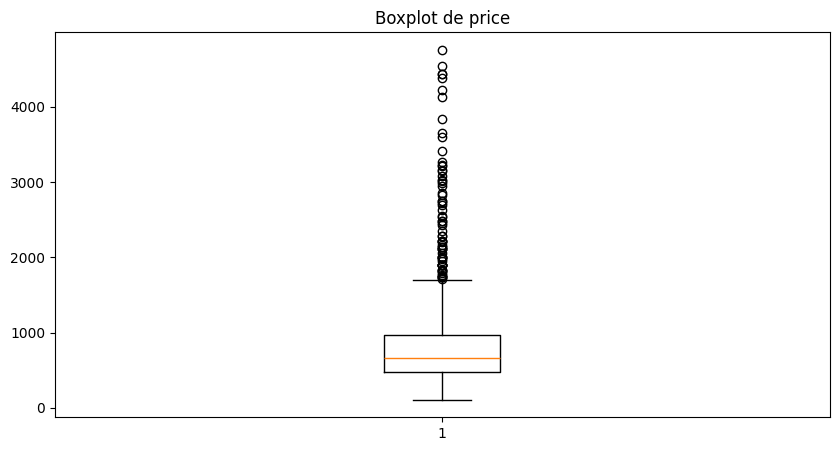

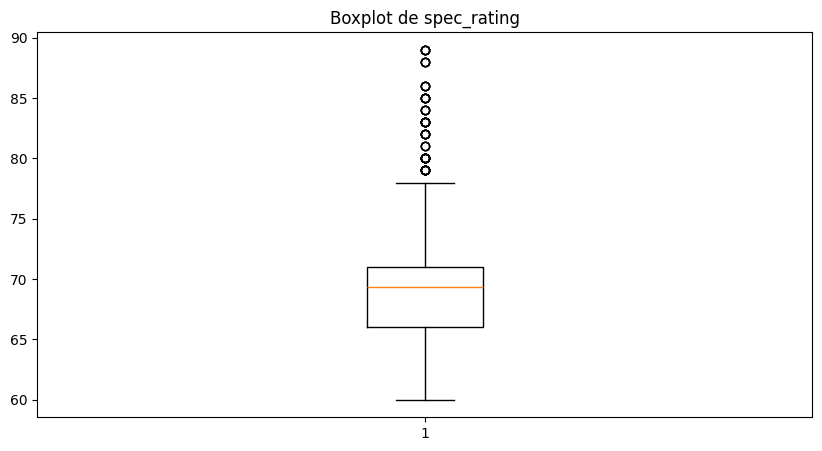

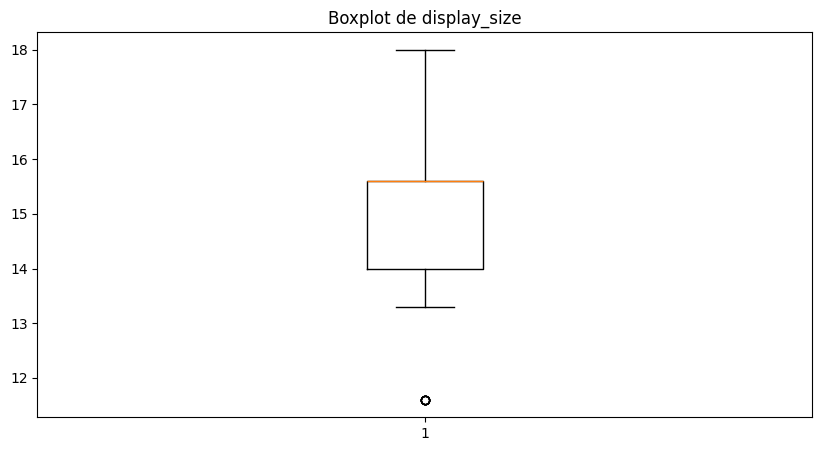

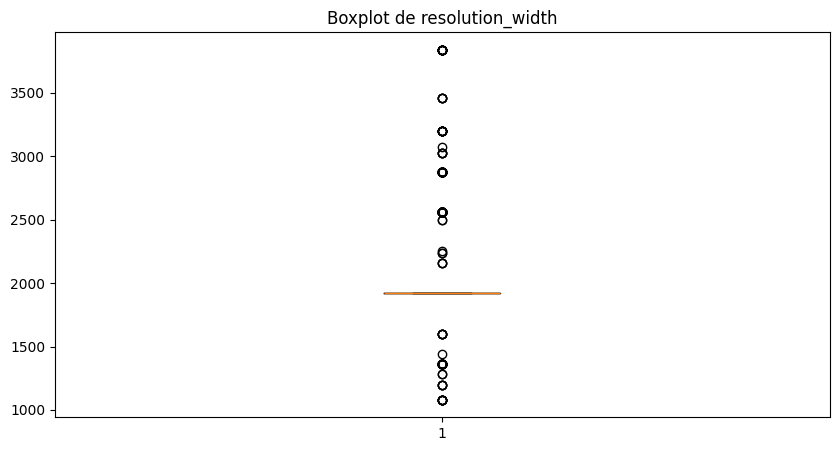

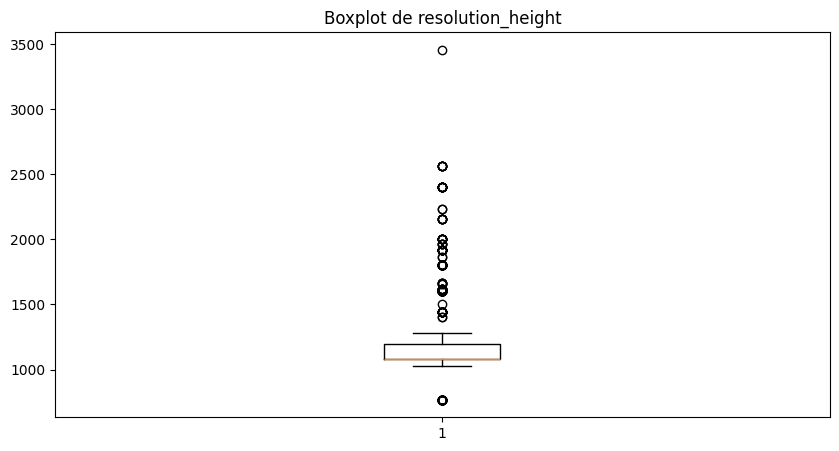

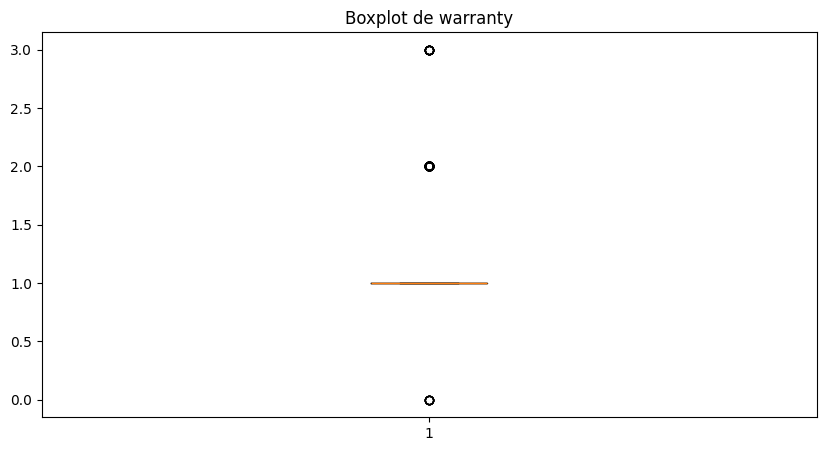

In [59]:
for col in num_col:
    plt.figure(figsize = (10,5))
    plt.boxplot(x = df[col])
    plt.title(f"Boxplot de {col}")
    colors = sns.color_palette("pastel")
    plt.show()

## 5. Limpieza de variables categóricas

Antes de poder usar las variables categóricas en un modelo, hay que estandarizarlas: unificar
etiquetas escritas de forma distinta para el mismo valor y agrupar categorías con muy pocas
observaciones para que el one-hot encoding no genere columnas casi vacías. La celda siguiente
resuelve, en orden:

1. **`OS`** — unifica variantes con doble espacio (`"Windows 11  OS"` → `"Windows 11 OS"`),
   reclasifica el genérico `"Windows OS"` como `"Windows 11 OS"`, y agrupa sistemas operativos
   con menos de 35 observaciones en `"Other OS"`.
2. **Columnas irrelevantes** — descarta `warranty` y `name` (no son características del producto
   en sí: `name` es un identificador, `warranty` no varía sistemáticamente con el precio de
   catálogo).
3. **`Ram_type`** — elimina la categoría casi vacía `"DDR"`, unifica sufijos (`"DDR4-"` →
   `"DDR4"`, `LPDDR4x/LPDDR4X` → `LPDDR4`, `LPDDR5x/LPDDR5X` → `LPDDR5`) y elimina las filas con
   `"DDR3"` o `"Unified"`.
4. **`display_size`** — consolida tamaños casi idénticos registrados con decimales distintos
   (ej. 15.56 y 15.30 → 15.60) y elimina filas con tamaños casi anecdóticos (15.00, 18.00, 11.60).
5. **`brand`** — agrupa marcas con menos de 45 observaciones en `"Other brand"`.
6. **`processor`** — exploración: se calcula el precio promedio por procesador solo para mirar
   la variabilidad; **no se usa directamente como variable** (ver la nota sobre *data leakage* en
   la siguiente sección).

In [60]:
df["OS"] = df["OS"].replace("Windows 11  OS", "Windows 11 OS")
df["OS"] = df["OS"].replace("Windows 10  OS", "Windows 10 OS")
df["OS"].value_counts()

df[df["OS"] == "Windows OS"]
df["OS"] = df["OS"].replace("Windows OS", "Windows 11 OS")
df["OS"].value_counts()

minorOS = df["OS"].value_counts()[df["OS"].value_counts() < 35].index
df.loc[df["OS"].isin(minorOS), "OS"] = "Other OS"
df.head()

df.drop(columns = ["warranty"], inplace = True)
df.head()
df.drop(columns = ["name"], inplace = True)

df.value_counts("Ram_type")
df.drop(df[df["Ram_type"] == "DDR"].index, inplace = True)
df["Ram_type"] = df["Ram_type"].replace("DDR4-", "DDR4")
df.value_counts("Ram_type")

df["Ram_type"] = df["Ram_type"].replace("LPDDR4x", "LPDDR4X")
df["Ram_type"] = df["Ram_type"].replace("LPDDR5x", "LPDDR5X")
df.drop(df[df["Ram_type"] == "DDR3"].index, inplace = True)
df.drop(df[df["Ram_type"] == "Unified"].index, inplace = True)
df.value_counts("Ram_type")

df["Ram_type"] = df["Ram_type"].replace("LPDDR5X", "LPDDR5")
df["Ram_type"] = df["Ram_type"].replace("LPDDR4X", "LPDDR4")
df.head()

df["display_size"].value_counts()
size_map = {
    15.56: 15.60,
    15.30: 15.60,
    13.50: 13.30,
    13.60: 13.30,
    17.0: 17.30,
    13.40: 13.30,
    14.1: 14.00,
    16.1: 16.00,
}
df["display_size"] = df["display_size"].replace(size_map)
df["display_size"].value_counts()

df.drop(df[df["display_size"] == 15.00].index, inplace = True)
df.drop(df[df["display_size"] == 18.00].index, inplace = True)
df.drop(df[df["display_size"] == 11.60].index, inplace = True)

df["brand"].value_counts()

low_marcas = df["brand"].value_counts()[df["brand"].value_counts() < 45].index
df.loc[df["brand"].isin(low_marcas), "brand"] = "Other brand"

df["processor"].value_counts()
df.groupby("processor")["price"].mean().sort_values(ascending = False)

processor
7th Gen AMD Ryzen 9  7945HX       4546.310002
13th Gen Intel Core i9 13950HX    4440.579404
6th Gen AMD Ryzen 9  6900HX       3594.734616
12th Gen Intel Core i9 12900H     3300.948051
13th Gen Intel Core i9 13980HX    3242.332769
                                     ...     
Intel Celeron  N4500               211.355466
Intel Celeron  N4020               211.355466
3rd Gen AMD Athlon 3050U           209.875238
AMD Athlon Pro 3045B               200.782406
Intel Celeron  N4020               168.182139
Name: price, Length: 174, dtype: float64

## 6. Ingeniería de variables: de texto libre a variables numéricas

La columna `processor` tiene demasiadas categorías únicas (una por modelo específico de chip)
para usarse tal cual en un one-hot encoding. En su lugar, se extrae la información relevante del
texto: la **marca** del procesador (Intel vs. AMD).

> **Nota sobre *data leakage* (una decisión importante):**
> En una versión anterior de este análisis se probó crear una variable de "gama del procesador" a
> partir del **precio promedio histórico de cada procesador** (el `groupby` de la celda anterior).
> Esa variable se eliminó del proyecto: usar el precio para construir una variable que luego se
> usa para predecir el precio es *data leakage* — el modelo estaría "haciendo trampa" viendo
> indirectamente la respuesta, y en producción sería imposible calcularla para un procesador
> nuevo sin conocer ya su precio.

In [61]:
cats_colV2 = df.select_dtypes(include = "object").columns
df[cats_colV2].value_counts()

# Detectar la marca del procesador segun el texto (columna separada de "brand",
# que ya es la marca del fabricante limpiada mas arriba - no la pisamos)
df["processor_brand"] = "Otro"
df.loc[df["processor"].str.contains("Ryzen", case=False, na=False), "processor_brand"] = "AMD"
df.loc[df["processor"].str.contains("Intel", case=False, na=False), "processor_brand"] = "Intel"

# NOTA: se elimino la segmentacion gama_procesador/segmento_procesador que habia aca antes.
# Calculaba terciles de precio promedio POR PROCESADOR (avg_price_by_proc = df.groupby("processor")["price"].mean())
# y los usaba como feature -> eso es data leakage: la columna ya "sabia" el precio antes de entrenar,
# y en produccion no se puede calcular el precio promedio de un procesador sin conocer el precio.
# Si se quiere una gama por procesador, hay que construirla sin usar price (ej. nucleos + generacion + processor_brand).

df["processor_brand"].value_counts()

C:\Users\Diego Monegro\AppData\Local\Temp\ipykernel_14900\1504683198.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cats_colV2 = df.select_dtypes(include = "object").columns


processor_brand
Intel    605
AMD      254
Otro      13
Name: count, dtype: int64

**Almacenamiento (`ROM`)** — se normalizan las etiquetas de texto (`"1TB"` → `"1024"`, `"2TB"` →
`"2048"`), se elimina la categoría casi anecdótica `"64GB"`, y se extrae el valor numérico (en GB)
con una expresión regular para tener una variable continua: `GB Storage`.

In [62]:
df["ROM"].value_counts()
df["ROM"] = df["ROM"].replace("1TB", "1024")
df["ROM"] = df["ROM"].replace("2TB", "2048")
df.drop(df[df["ROM"] == "64GB"].index, inplace = True)

df["GB Storage"] = df["ROM"].str.extract(r'(\d+)').astype(int)
df["GB Storage"].value_counts()


GB Storage
512     629
1024    181
256      40
2048     10
128       9
Name: count, dtype: int64

## 7. Chequeo intermedio: correlaciones y cardinalidad

Revisamos cómo van relacionándose las variables numéricas entre sí (vigilando la multicolinealidad
de la sección 3) y cuántas categorías únicas quedan en cada variable categórica.

<Axes: >

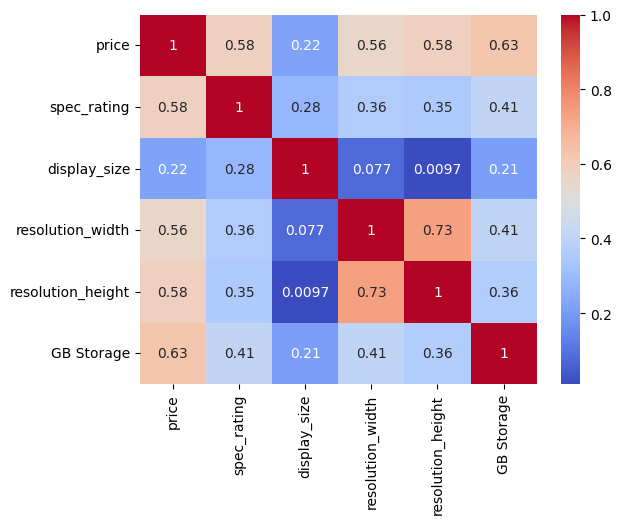

In [63]:
crmtx = df.corr(numeric_only=True)

sns.heatmap(crmtx, annot=True, cmap="coolwarm")

In [64]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols.value_counts()
df[cat_cols].nunique()

C:\Users\Diego Monegro\AppData\Local\Temp\ipykernel_14900\526648386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


brand                7
processor          174
CPU                 25
Ram                  6
Ram_type             4
ROM                  5
ROM_type             2
GPU                124
OS                   3
processor_brand      3
dtype: int64

Aquí se normalizan las últimas variantes de texto de `ROM` (`"512GB"`, `"256GB"`, `"128GB"`) a
valores puramente numéricos, dejando la columna más legible durante la exploración — aunque, como
se ve más adelante, `ROM` termina descartándose en favor de `GB Storage`, que ya es numérica.

In [65]:

df['ROM'] = df['ROM'].replace("1TB", "1024")
df['ROM'] = df['ROM'].replace("2TB", "2048")
df['ROM'] = df['ROM'].replace("512GB", "512")
df['ROM'] = df['ROM'].replace("256GB", "256")
df['ROM'] = df['ROM'].replace("128GB", "128")


In [66]:
df

,brand,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,processor_brand,GB Storage
0,HP,527.595686,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8GB,DDR4,512,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,Windows 11 OS,AMD,512
1,HP,421.865088,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512,SSD,Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,Intel,512
2,Acer,285.366885,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8GB,DDR4,512,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,Intel,512
3,Lenovo,631.518291,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16GB,LPDDR5,512,SSD,Intel Integrated Iris Xe,14.0,2240.0,1400.0,Windows 11 OS,Intel,512
4,Other brand,740.008458,69.323529,Apple M1,Octa Core (4P + 4E),8GB,DDR4,256,SSD,Apple M1 Integrated Graphics,13.3,2560.0,1600.0,Other OS,Otro,256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,Acer,602.558680,69.323529,13th Gen Intel Core i5 1335U,"10 Cores (2P + 8E), 12 Threads",16GB,LPDDR5,512,SSD,Intel Integrated Iris Xe,15.6,1920.0,1080.0,Windows 11 OS,Intel,512
888,Asus,475.681962,69.323529,13th Gen ‎Intel Core i3 1315U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512,SSD,Integrated Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,Intel,512
890,Asus,2008.775640,89.000000,7th Gen AMD Ryzen 9 7940HS,"Octa Core, 16 Threads",32GB,DDR5,1024,SSD,8GB NVIDIA GeForce RTX 4060,14.0,2560.0,1600.0,Windows 11 OS,AMD,1024
891,Asus,1374.392049,73.000000,13th Gen Intel Core i7 13700H,"14 Cores (6P + 8E), 20 Threads",16GB,DDR4,512,SSD,6GB NVIDIA GeForce RTX 4050,15.6,1920.0,1080.0,Windows 11 OS,Intel,512


<Axes: >

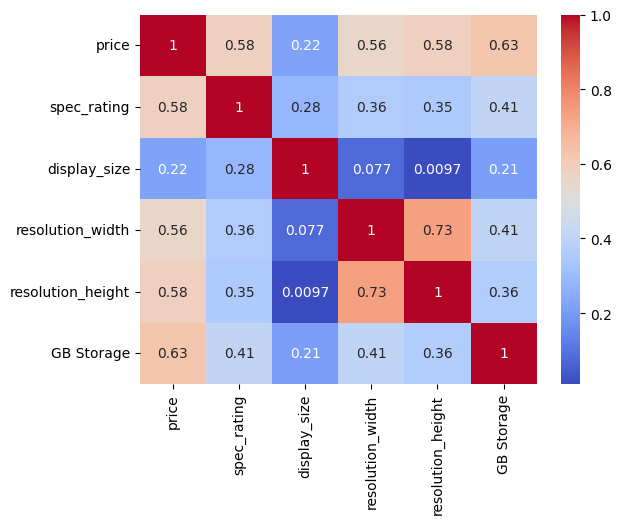

In [67]:
crmtx = df.corr(numeric_only=True)

sns.heatmap(crmtx, annot=True, cmap="coolwarm")

## 8. Transformando variables numéricas sesgadas

El precio de una laptop, igual que la RAM o el poder de GPU, no se distribuye de forma simétrica:
hay muchos modelos "de gama media" y relativamente pocos de gama muy alta, lo que genera una
**cola larga hacia la derecha**. Esa asimetría afecta el supuesto de linealidad/normalidad de la
sección 3, así que se aplica `log1p` (logaritmo de 1+x) a las variables más sesgadas.

In [68]:
df['Ram'].value_counts()

Ram
16GB    451
8GB     360
32GB     38
4GB      16
12GB      2
64GB      2
Name: count, dtype: int64

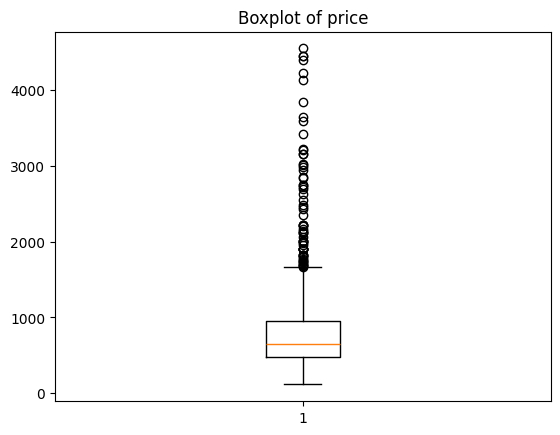

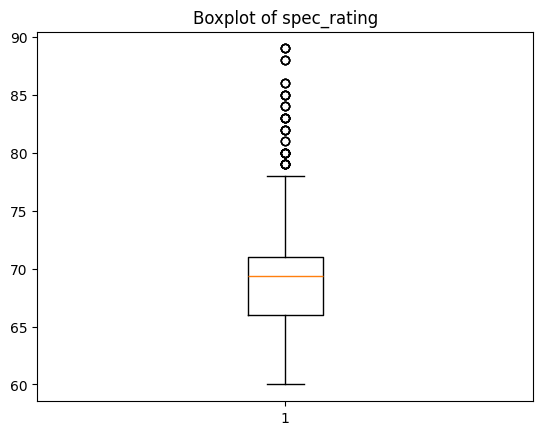

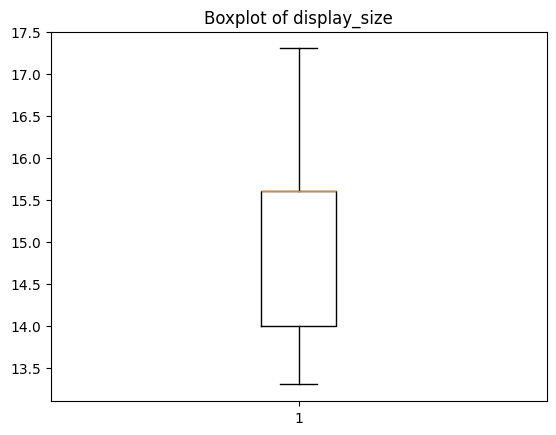

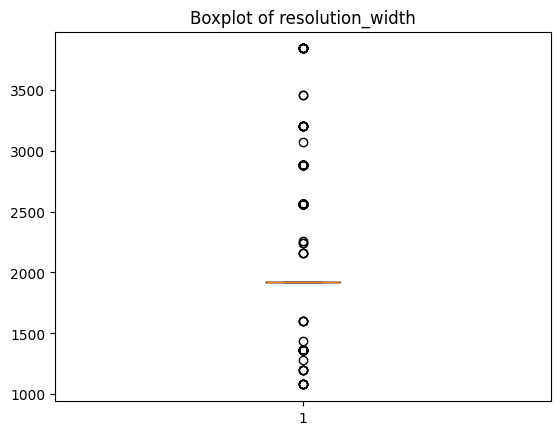

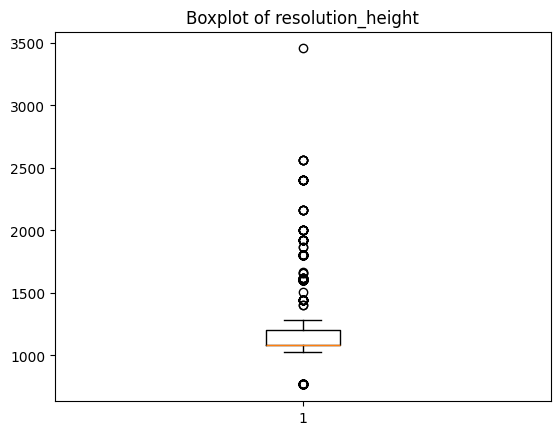

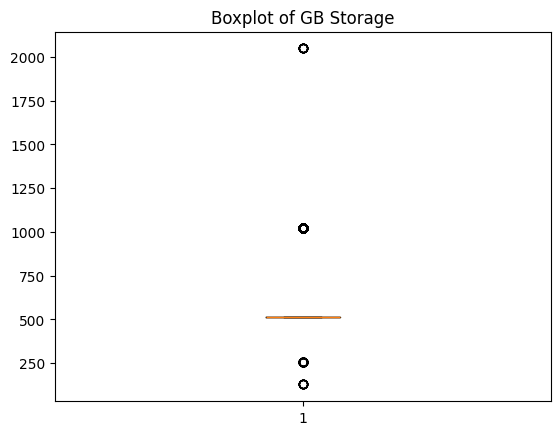

In [69]:
num_colsV3 = df.select_dtypes(include=['number']).columns

for col in num_colsV3:
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Transformación logarítmica del precio, comparando el boxplot antes/después:

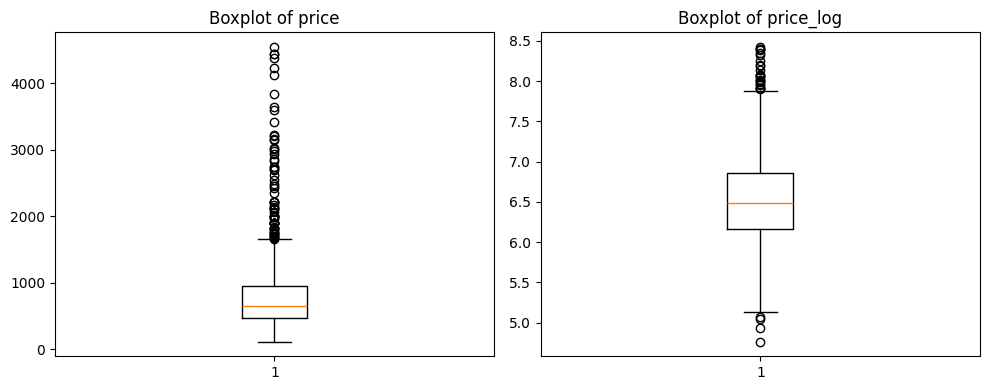

In [70]:
import numpy as np

# Log transform (log1p maneja bien el caso de que hubiera algún 0, aunque en price no debería)
df['price_log'] = np.log1p(df['price'])

# Comparar distribución antes y después
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(df['price'])
axes[0].set_title('Boxplot of price')

axes[1].boxplot(df['price_log'])
axes[1].set_title('Boxplot of price_log')

plt.tight_layout()
plt.show()

A partir de aquí, **`price_log` es la variable respuesta del modelo**; `price` (en dólares) ya
cumplió su función y se descarta.

In [71]:
df.drop(columns=['price'], inplace=True)


Igual que con el precio, se aplica una transformación logarítmica a `Ram` (aunque, como se ve más
adelante, la versión final del modelo termina usando `Ram` en su escala original y descarta
`Ram_log`):

In [72]:
df['Ram'] = df['Ram'].replace("64GB", "64")
df['Ram'] = df['Ram'].replace("32GB", "32")
df['Ram'] = df['Ram'].replace("16GB", "16")
df['Ram'] = df['Ram'].replace("8GB", "8")
df['Ram'] = df['Ram'].replace("4GB", "4")
df['Ram'] = df['Ram'].replace("12GB", "12")
df['Ram'] = df['Ram'].astype(int)
df['Ram_log'] = np.log1p(df['Ram'])
df['Ram'].value_counts()

Ram
16    451
8     360
32     38
4      16
12      2
64      2
Name: count, dtype: int64

<Axes: >

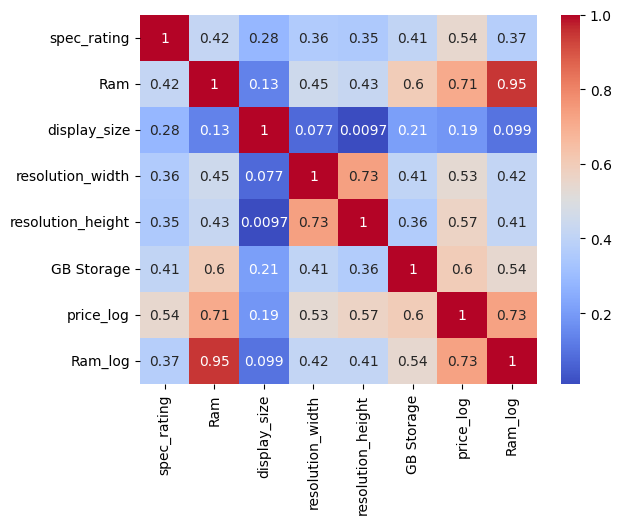

In [73]:
corra = df.corr(numeric_only=True)

sns.heatmap(corra, annot=True, cmap="coolwarm")

In [74]:
df

,brand,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,processor_brand,GB Storage,price_log,Ram_log
0,HP,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8,DDR4,512,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,Windows 11 OS,AMD,512,6.270224,2.197225
1,HP,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8,DDR4,512,SSD,Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,Intel,512,6.047053,2.197225
2,Acer,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8,DDR4,512,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,Intel,512,5.657274,2.197225
3,Lenovo,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16,LPDDR5,512,SSD,Intel Integrated Iris Xe,14.0,2240.0,1400.0,Windows 11 OS,Intel,512,6.449709,2.833213
4,Other brand,69.323529,Apple M1,Octa Core (4P + 4E),8,DDR4,256,SSD,Apple M1 Integrated Graphics,13.3,2560.0,1600.0,Other OS,Otro,256,6.608012,2.197225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,Acer,69.323529,13th Gen Intel Core i5 1335U,"10 Cores (2P + 8E), 12 Threads",16,LPDDR5,512,SSD,Intel Integrated Iris Xe,15.6,1920.0,1080.0,Windows 11 OS,Intel,512,6.402843,2.833213
888,Asus,69.323529,13th Gen ‎Intel Core i3 1315U,"Hexa Core (2P + 4E), 8 Threads",8,DDR4,512,SSD,Integrated Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,Intel,512,6.166850,2.197225
890,Asus,89.000000,7th Gen AMD Ryzen 9 7940HS,"Octa Core, 16 Threads",32,DDR5,1024,SSD,8GB NVIDIA GeForce RTX 4060,14.0,2560.0,1600.0,Windows 11 OS,AMD,1024,7.605778,3.496508
891,Asus,73.000000,13th Gen Intel Core i7 13700H,"14 Cores (6P + 8E), 20 Threads",16,DDR4,512,SSD,6GB NVIDIA GeForce RTX 4050,15.6,1920.0,1080.0,Windows 11 OS,Intel,512,7.226494,2.833213


## 9. Enfocando el modelo en las dos marcas dominantes de procesador

`processor_brand` quedó con muy pocas observaciones fuera de Intel y AMD (chips poco comunes o no
identificados por el texto). Para no introducir una categoría "Otro" casi vacía en el one-hot
encoding, se eliminan esas filas.

In [75]:
df = df.drop(df[df['processor_brand'] == 'Otro'].index)

In [76]:
df['processor_brand'].value_counts()

processor_brand
Intel    602
AMD      254
Name: count, dtype: int64

### Núcleos del procesador (`CPU`)

La columna `CPU` describe la configuración de núcleos e hilos en texto libre, de dos formas
distintas: como número explícito (`"10 Cores (2P + 8E), 12 Threads"`) o como palabra
(`"Quad Core, 8 Threads"`). Se aplica conocimiento de arquitectura de procesadores (dual = 2,
quad = 4, hexa = 6, octa = 8) para convertir ambos formatos en una sola variable numérica: número
de núcleos.

Donde esta presenta cierto ruido el cual, el conocimiento dentro del sector ayuda bastante.

Recolocar los nucleos del procesador siendo la parte vital dentro de este crea una variable mas enriquecedora a la hora
de predecir un modelo.

In [77]:
df['CPU'].value_counts()

import re
import numpy as np

# Mapeo de nombres en palabras a número de núcleos
palabra_a_nucleos = {
    "dual": 2,
    "quad": 4,
    "hexa": 6,
    "octa": 8,
}

def extraer_nucleos(cpu_str):
    # Caso 1: viene como número explícito, ej. "10 Cores (2P + 8E), 12 Threads"
    match = re.match(r'(\d+)\s*Cores?', cpu_str, flags=re.IGNORECASE)
    if match:
        return int(match.group(1))
    
    # Caso 2: viene como palabra, ej. "Quad Core, 8 Threads"
    cpu_lower = cpu_str.lower()
    for palabra, num in palabra_a_nucleos.items():
        if palabra in cpu_lower:
            return num
    
    # No se pudo determinar (ej. "20 Threads" sin info de núcleos)
    return np.nan

df["nucleos"] = df["CPU"].apply(extraer_nucleos)

# Revisar si quedó algo sin convertir
print(df.loc[df["nucleos"].isna(), "CPU"].value_counts())


CPU
20 Threads    1
Name: count, dtype: int64


In [78]:
df = df[df["nucleos"].notna()].reset_index(drop=True)
df

,brand,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,processor_brand,GB Storage,price_log,Ram_log,nucleos
0,HP,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8,DDR4,512,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,Windows 11 OS,AMD,512,6.270224,2.197225,6.0
1,HP,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8,DDR4,512,SSD,Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,Intel,512,6.047053,2.197225,6.0
2,Acer,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8,DDR4,512,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,Intel,512,5.657274,2.197225,2.0
3,Lenovo,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16,LPDDR5,512,SSD,Intel Integrated Iris Xe,14.0,2240.0,1400.0,Windows 11 OS,Intel,512,6.449709,2.833213,12.0
4,Acer,62.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",8,DDR4,512,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,Intel,512,6.049301,2.197225,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
850,Acer,69.323529,13th Gen Intel Core i5 1335U,"10 Cores (2P + 8E), 12 Threads",16,LPDDR5,512,SSD,Intel Integrated Iris Xe,15.6,1920.0,1080.0,Windows 11 OS,Intel,512,6.402843,2.833213,10.0
851,Asus,69.323529,13th Gen ‎Intel Core i3 1315U,"Hexa Core (2P + 4E), 8 Threads",8,DDR4,512,SSD,Integrated Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,Intel,512,6.166850,2.197225,6.0
852,Asus,89.000000,7th Gen AMD Ryzen 9 7940HS,"Octa Core, 16 Threads",32,DDR5,1024,SSD,8GB NVIDIA GeForce RTX 4060,14.0,2560.0,1600.0,Windows 11 OS,AMD,1024,7.605778,3.496508,8.0
853,Asus,73.000000,13th Gen Intel Core i7 13700H,"14 Cores (6P + 8E), 20 Threads",16,DDR4,512,SSD,6GB NVIDIA GeForce RTX 4050,15.6,1920.0,1080.0,Windows 11 OS,Intel,512,7.226494,2.833213,14.0


Con `nucleos` (numérica) y `processor_brand` (categórica) ya calculadas, las columnas de texto
libre `CPU` y `processor` se descartan: ya cumplieron su propósito.

In [79]:
df.drop(['CPU'], axis=1, inplace=True)
df.drop(['processor'], axis=1, inplace=True)

## 10. GPU: el ejemplo más claro de "traducir hardware en números"

La columna `GPU` es, con diferencia, la más difícil de estandarizar: describe modelo, marca, VRAM
y a veces términos como "Integrated" o "Max-Q", todo en texto libre y con inconsistencias de
formato (typos, mayúsculas mezcladas, nombres incompletos).

Esta sección es también la que mejor ilustra el objetivo de este proyecto: **combinar
conocimiento de computación (qué es una GPU, qué modelos existen, qué tan potente es cada uno en
TFLOPS) con técnica de ciencia de datos (parsing con expresiones regulares, normalización de
texto, manejo de categorías raras, imputación razonada)** para convertir una columna de texto en
una variable numérica que el modelo pueda usar: el rendimiento estimado en TFLOPS.

In [80]:
df['GPU'].value_counts()

GPU
Intel Iris Xe Graphics          107
Intel UHD Graphics               63
Intel Integrated UHD             55
AMD Radeon AMD                   55
Intel Integrated Iris Xe         51
                               ... 
2GB NVIDIA GeForce MX570          1
4GB NVIDIA GeForce GTX 1650       1
6GB NVIDIA GEFORCE RTX 4050       1
Intel UHD Integrated              1
4GB AMD Radeon RX 5600M           1
Name: count, Length: 120, dtype: int64

In [81]:
print(df["GPU"].unique())

<StringArray>
[      '4GB AMD Radeon RX 6500M',            'Intel UHD Graphics',
        'Intel Iris Xe Graphics',      'Intel Integrated Iris Xe',
   '6GB NVIDIA GeForce RTX 4050',                 'Intel Iris Xe',
          'Intel Integrated UHD', 'Intel Integrated UHD Graphics',
   '4GB NVIDIA GeForce RTX 3050',           'AMD Radeon Graphics',
 ...
                     'Intel UHD',   '8GB Nvidia GeForce RTX 4060',
   '6GB Nvidia GeForce RTX 4050',      '2GB NVIDIA GeForce MX570',
   '8GB NVIDIA Geforce RTX 4060',           '4GB Nvidia RTX 3050',
  '4GB NVIDIA GeForce GTX 1650 ',   '6GB NVIDIA GEFORCE RTX 4050',
          'Intel UHD Integrated',      '4GB AMD Radeon RX 5600M ']
Length: 120, dtype: str


**Paso 1 — marca de la GPU**

In [82]:
df["gpu_brand"] = "Otro"
df.loc[df["GPU"].str.contains("NVIDIA|GeForce|RTX|GTX|Quadro", case=False, na=False), "gpu_brand"] = "Nvidia"
df.loc[df["GPU"].str.contains("AMD|Radeon", case=False, na=False), "gpu_brand"] = "AMD"
df.loc[df["GPU"].str.contains("Intel|Iris|UHD Graphics|Arc", case=False, na=False), "gpu_brand"] = "Intel"

print(df["gpu_brand"].value_counts())


gpu_brand
Intel     388
Nvidia    303
AMD       164
Name: count, dtype: int64


**Paso 2 — primer intento de mapear a TFLOPS**

Un primer diccionario manual, construido con las especificaciones publicadas de cada modelo,
muestra que hace falta limpiar antes el texto (hay demasiadas variantes del mismo modelo) para
poder mapear de forma consistente.

In [83]:
teraflops_map = {
    "RTX 4060": 15.11,
    "RTX 3050": 6.6,
    "Radeon RX 6600M": 8.5,
    "Iris Xe Graphics": 1.7,
    # ... agrega uno por cada modelo único que viste en el Paso 1
}

df["teraflops"] = df["GPU"].map(teraflops_map)

# Verificar si algún modelo quedó sin mapear
print(df.loc[df["teraflops"].isna(), "GPU"].unique())


<StringArray>
[      '4GB AMD Radeon RX 6500M',            'Intel UHD Graphics',
        'Intel Iris Xe Graphics',      'Intel Integrated Iris Xe',
   '6GB NVIDIA GeForce RTX 4050',                 'Intel Iris Xe',
          'Intel Integrated UHD', 'Intel Integrated UHD Graphics',
   '4GB NVIDIA GeForce RTX 3050',           'AMD Radeon Graphics',
 ...
                     'Intel UHD',   '8GB Nvidia GeForce RTX 4060',
   '6GB Nvidia GeForce RTX 4050',      '2GB NVIDIA GeForce MX570',
   '8GB NVIDIA Geforce RTX 4060',           '4GB Nvidia RTX 3050',
  '4GB NVIDIA GeForce GTX 1650 ',   '6GB NVIDIA GEFORCE RTX 4050',
          'Intel UHD Integrated',      '4GB AMD Radeon RX 5600M ']
Length: 119, dtype: str


**Paso 3 — limpieza de texto (primera pasada)**

In [84]:
import re

def limpiar_gpu(gpu_str):
    s = gpu_str.strip()
    # Quitar el prefijo de VRAM, ej "4GB ", "8GB "
    s = re.sub(r'^\d+GB\s*', '', s, flags=re.IGNORECASE)
    # Normalizar espacios múltiples/sobrantes
    s = re.sub(r'\s+', ' ', s).strip()
    # Normalizar capitalización de marcas/palabras clave
    s = re.sub(r'nvidia', 'NVIDIA', s, flags=re.IGNORECASE)
    s = re.sub(r'geforce', 'GeForce', s, flags=re.IGNORECASE)
    s = re.sub(r'\bamd\b', 'AMD', s, flags=re.IGNORECASE)
    s = re.sub(r'\bintel\b', 'Intel', s, flags=re.IGNORECASE)
    # Quitar la palabra "Integrated" (redundante en las integradas)
    s = re.sub(r'\bIntegrated\b\s*', '', s, flags=re.IGNORECASE).strip()
    return s

df["GPU_clean"] = df["GPU"].apply(limpiar_gpu)

modelos_unicos = sorted(df["GPU_clean"].unique())
print(modelos_unicos)
print(f"\nModelos únicos: {df['GPU_clean'].nunique()} (antes de limpiar: {df['GPU'].nunique()})")


['AMD Graphics', 'AMD Radeon', 'AMD Radeon 610M', 'AMD Radeon 610M Graphics', 'AMD Radeon 680M', 'AMD Radeon 7 Graphics', 'AMD Radeon 780M Graphics', 'AMD Radeon AMD', 'AMD Radeon AMD Radeon RX 6500M', 'AMD Radeon Graphics', 'AMD Radeon Graphiics', 'AMD Radeon RX 5600M', 'AMD Radeon RX 6500M', 'AMD Radeon RX 6500M Graphics', 'AMD Radeon RX 6650M', 'AMD Radeon RX6500M', 'AMD Radeon RX6550M', 'AMD Radeon Radeon', 'AMD Radeon Radeon Graphics', 'AMD Radeon Vega 6', 'AMD Radeon Vega 7', 'AMD Radeon Vega 7 Graphics', 'AMD Radeon Vega 8', 'AMD Radeon Vega 8 Graphics', 'AMD SoC', 'GB NVIDIA GeForce RTX 2050', 'GeForce MX130', 'Intel', 'Intel Arc A350M Graphics', 'Intel Graphics', 'Intel HD', 'Intel Intel Iris Xe Graphics', 'Intel Intel UHD', 'Intel Intel UHD Graphics', 'Intel Intel® UHD Graphics', 'Intel Iris', 'Intel Iris Plus', 'Intel Iris X Graphics', 'Intel Iris XE Graphics', 'Intel Iris Xe', 'Intel Iris Xe Graphic', 'Intel Iris Xe Graphics', 'Intel UHD', 'Intel UHD 600', 'Intel UHD Graphi

*(checkpoint rápido, no relacionado con GPU)*

In [85]:
df['processor_brand'].value_counts()

processor_brand
Intel    601
AMD      254
Name: count, dtype: int64

**Paso 4 — limpieza de texto (segunda pasada, corrigiendo typos específicos del dataset)**

In [86]:
import re

TYPO_FIXES = {
    "Graphiics": "Graphics",
    "Intel®": "Intel",
    "RX6500M": "RX 6500M",
    "RX6550M": "RX 6550M",
    "GTX1650": "GTX 1650",
    "RTX2050": "RTX 2050",
    "RTX3070Ti": "RTX 3070 Ti",
    "GeForce GTX 2050": "GeForce RTX 2050",  # GTX 2050 no existe, es RTX 2050
    "GeForce GTX 3050": "GeForce RTX 3050",  # GTX 3050 no existe, es RTX 3050
    "Max Q": "Max-Q",
    "iris": "Iris",
    "XE": "Xe",
}

FILLER_WORDS = {"graphics", "graphic", "gpu"}
BRAND_TOKENS = {"amd", "nvidia", "intel", "radeon", "geforce", "rtx", "gtx", "uhd", "iris", "xe"}

def limpiar_gpu_final(s):
    for typo, fix in TYPO_FIXES.items():
        s = s.replace(typo, fix)
    s = re.sub(r'^\d*GB\s*', '', s, flags=re.IGNORECASE)  # restos de VRAM sin dígito

    palabras = s.split()
    vistas = set()
    resultado = []
    for p in palabras:
        clave = p.lower()
        if clave in FILLER_WORDS:
            continue  # quitar relleno
        if clave in BRAND_TOKENS:
            if clave in vistas:
                continue  # quitar duplicado de marca/serie
            vistas.add(clave)
        resultado.append(p)
    s = " ".join(resultado).strip()

    # Agregar marca si falta
    s_lower = s.lower()
    if not any(m in s_lower for m in ["amd", "nvidia", "intel"]):
        if any(k in s_lower for k in ["geforce", "rtx", "gtx", "mx", "quadro"]):
            s = "NVIDIA " + s
        elif any(k in s_lower for k in ["radeon", "vega"]):
            s = "AMD " + s
        elif any(k in s_lower for k in ["uhd", "iris", "hd"]):
            s = "Intel " + s
    return s

df["GPU_final"] = df["GPU_clean"].apply(limpiar_gpu_final)
print(sorted(df["GPU_final"].unique()))
print(f"\nModelos únicos: {df['GPU_final'].nunique()}")


['AMD', 'AMD Radeon', 'AMD Radeon 610M', 'AMD Radeon 680M', 'AMD Radeon 7', 'AMD Radeon 780M', 'AMD Radeon Pro 5500M', 'AMD Radeon RX 5600M', 'AMD Radeon RX 6500M', 'AMD Radeon RX 6550M', 'AMD Radeon RX 6650M', 'AMD Radeon Vega 6', 'AMD Radeon Vega 7', 'AMD Radeon Vega 8', 'AMD SoC', 'Intel', 'Intel Arc A350M', 'Intel HD', 'Intel Iris', 'Intel Iris Plus', 'Intel Iris X', 'Intel Iris Xe', 'Intel UHD', 'Intel UHD 600', 'Intel UHD 620', 'Intel UHD 630', 'NVIDIA', 'NVIDIA GTX 1650', 'NVIDIA GeForce GTX 1050Ti', 'NVIDIA GeForce GTX 1650', 'NVIDIA GeForce GTX 1650 Max-Q', 'NVIDIA GeForce MX130', 'NVIDIA GeForce MX250', 'NVIDIA GeForce MX350', 'NVIDIA GeForce MX450', 'NVIDIA GeForce MX570', 'NVIDIA GeForce RTX', 'NVIDIA GeForce RTX 2050', 'NVIDIA GeForce RTX 3050', 'NVIDIA GeForce RTX 3050 Ti', 'NVIDIA GeForce RTX 3060', 'NVIDIA GeForce RTX 3070 Ti', 'NVIDIA GeForce RTX 3070Ti', 'NVIDIA GeForce RTX 3080 Ti', 'NVIDIA GeForce RTX 4050', 'NVIDIA GeForce RTX 4060', 'NVIDIA GeForce RTX 4070', 'NVI

**Paso 5 — mapeo completo a TFLOPS**

Con el texto ya estandarizado, se completa el diccionario de TFLOPS por modelo (a partir de
especificaciones publicadas por los fabricantes):

In [87]:
teraflops_map = {
    # AMD
    "AMD Radeon 610M": 0.6, "AMD Radeon 680M": 3.4, "AMD Radeon 7": 1.6,
    "AMD Radeon 780M": 5.4, "AMD Radeon RX 5600M": 7.2, "AMD Radeon RX 6500M": 4.5,
    "AMD Radeon RX 6550M": 5.7, "AMD Radeon RX 6650M": 6.6, "AMD Radeon Vega 6": 1.1,
    "AMD Radeon Vega 7": 1.6, "AMD Radeon Vega 8": 1.9, "AMD Radeon Pro 5500M": 4.0,
    # Intel
    "Intel Arc A350M": 2.6, "Intel Iris Xe": 2.0, "Intel Iris Plus": 1.1,
    "Intel Iris": 1.0, "Intel UHD": 0.4, "Intel UHD 600": 0.3, "Intel UHD 630": 0.4,
    # NVIDIA
    "NVIDIA GTX 1650": 3.0, "NVIDIA GeForce GTX 1050 Ti": 2.1, "NVIDIA GeForce GTX 1650": 3.0,
    "NVIDIA GeForce GTX 1650 Max-Q": 2.5, "NVIDIA GeForce MX130": 0.6, "NVIDIA GeForce MX250": 1.2,
    "NVIDIA GeForce MX350": 1.3, "NVIDIA GeForce MX450": 1.9, "NVIDIA GeForce MX570": 2.1,
    "NVIDIA GeForce RTX 2050": 3.7, "NVIDIA GeForce RTX 3050": 6.6, "NVIDIA GeForce RTX 3050 Ti": 7.7,
    "NVIDIA GeForce RTX 3060": 10.9, "NVIDIA GeForce RTX 3070 Ti": 16.6, "NVIDIA GeForce RTX 3080 Ti": 20.8,
    "NVIDIA GeForce RTX 4050": 9.5, "NVIDIA GeForce RTX 4060": 11.6, "NVIDIA GeForce RTX 4070": 14.6,
    "NVIDIA GeForce RTX 4080": 34.0, "NVIDIA GeForce RTX 4090": 41.0,
    "NVIDIA GeForce RTX A1000": 4.3, "NVIDIA GeForce RTX A2000 Ada": 8.9,
    "NVIDIA Quadro T600": 2.5, "NVIDIA RTX 3000 Ada": 9.6, "NVIDIA RTX 3050": 6.6,
    "NVIDIA RTX 4050": 9.5, "NVIDIA RTX A500": 2.9,
}

df["teraflops"] = df["GPU_final"].map(teraflops_map)
print(df.loc[df["teraflops"].isna(), "GPU_final"].value_counts())


GPU_final
AMD Radeon                   131
Intel                         21
Intel Iris X                   3
AMD                            2
Intel HD                       2
NVIDIA GeForce RTX 3070Ti      2
AMD SoC                        2
NVIDIA                         1
Intel UHD 620                  1
NVIDIA GeForce GTX 1050Ti      1
NVIDIA GeForce RTX             1
Name: count, dtype: int64


In [88]:
# Corregir problemas de espaciado/typos puntuales
df["GPU_final"] = df["GPU_final"].str.replace("RTX 3070Ti", "RTX 3070 Ti", regex=False)
df["GPU_final"] = df["GPU_final"].str.replace("GTX 1050Ti", "GTX 1050 Ti", regex=False)
df["GPU_final"] = df["GPU_final"].str.replace(r"\bIris X\b", "Iris Xe", regex=True)

# Agregar entradas que faltaban en el diccionario
teraflops_map["Intel UHD 620"] = 0.4
teraflops_map["Intel HD"] = 0.35

# Volver a mapear
df["teraflops"] = df["GPU_final"].map(teraflops_map)
print(df.loc[df["teraflops"].isna(), "GPU_final"].value_counts())


GPU_final
AMD Radeon            131
Intel                  21
AMD                     2
AMD SoC                 2
NVIDIA                  1
NVIDIA GeForce RTX      1
Name: count, dtype: int64


**Paso 6 — casos residuales**

Las GPU integradas genéricas de AMD (`"AMD Radeon"`, `"AMD"` sin más detalle) no corresponden a un
modelo específico, así que se les asigna el promedio de TFLOPS de las iGPU Radeon conocidas. Las
pocas filas que aún así queden sin mapear se descartan.

In [89]:
igpu_generica = ["AMD Radeon 610M", "AMD Radeon Vega 6", "AMD Radeon Vega 7", "AMD Radeon Vega 8"]
promedio_amd_radeon = sum(teraflops_map[k] for k in igpu_generica) / len(igpu_generica)
print(promedio_amd_radeon)  # ≈ 1.3

df.loc[df["GPU_final"].isin(["AMD Radeon", "AMD"]), "teraflops"] = promedio_amd_radeon

filas_antes = len(df)
df = df[df["teraflops"].notna()].reset_index(drop=True)
print(f"Filas eliminadas: {filas_antes - len(df)} de {filas_antes}")


1.3
Filas eliminadas: 25 de 855


Con `teraflops` ya numérica, se aplica la misma transformación logarítmica que a `price` (la
potencia de GPU también está muy sesgada: hay muchas más laptops con GPU integrada modesta que con
GPU dedicadas de gama alta):

In [90]:
df["teraflops_log"] = np.log1p(df["teraflops"])

In [91]:
df

,brand,spec_rating,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,...,processor_brand,GB Storage,price_log,Ram_log,nucleos,gpu_brand,teraflops,GPU_clean,GPU_final,teraflops_log
0,HP,73.000000,8,DDR4,512,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,...,AMD,512,6.270224,2.197225,6.0,AMD,4.5,AMD Radeon RX 6500M,AMD Radeon RX 6500M,1.704748
1,HP,60.000000,8,DDR4,512,SSD,Intel UHD Graphics,15.6,1920.0,1080.0,...,Intel,512,6.047053,2.197225,6.0,Intel,0.4,Intel UHD Graphics,Intel UHD,0.336472
2,Acer,69.323529,8,DDR4,512,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,...,Intel,512,5.657274,2.197225,2.0,Intel,2.0,Intel Iris Xe Graphics,Intel Iris Xe,1.098612
3,Lenovo,66.000000,16,LPDDR5,512,SSD,Intel Integrated Iris Xe,14.0,2240.0,1400.0,...,Intel,512,6.449709,2.833213,12.0,Intel,2.0,Intel Iris Xe,Intel Iris Xe,1.098612
4,Acer,62.000000,8,DDR4,512,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,...,Intel,512,6.049301,2.197225,12.0,Intel,2.0,Intel Iris Xe Graphics,Intel Iris Xe,1.098612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
825,Acer,69.323529,16,LPDDR5,512,SSD,Intel Integrated Iris Xe,15.6,1920.0,1080.0,...,Intel,512,6.402843,2.833213,10.0,Intel,2.0,Intel Iris Xe,Intel Iris Xe,1.098612
826,Asus,69.323529,8,DDR4,512,SSD,Integrated Intel UHD Graphics,15.6,1920.0,1080.0,...,Intel,512,6.166850,2.197225,6.0,Intel,0.4,Intel UHD Graphics,Intel UHD,0.336472
827,Asus,89.000000,32,DDR5,1024,SSD,8GB NVIDIA GeForce RTX 4060,14.0,2560.0,1600.0,...,AMD,1024,7.605778,3.496508,8.0,Nvidia,11.6,NVIDIA GeForce RTX 4060,NVIDIA GeForce RTX 4060,2.533697
828,Asus,73.000000,16,DDR4,512,SSD,6GB NVIDIA GeForce RTX 4050,15.6,1920.0,1080.0,...,Intel,512,7.226494,2.833213,14.0,Nvidia,9.5,NVIDIA GeForce RTX 4050,NVIDIA GeForce RTX 4050,2.351375


Las columnas de texto intermedias ya cumplieron su función y se descartan, quedándonos con
`gpu_brand` y `teraflops_log`.

In [92]:
df = df.drop(columns=["GPU_clean", "GPU_final", "GPU"])


In [93]:
df

,brand,spec_rating,Ram,Ram_type,ROM,ROM_type,display_size,resolution_width,resolution_height,OS,processor_brand,GB Storage,price_log,Ram_log,nucleos,gpu_brand,teraflops,teraflops_log
0,HP,73.000000,8,DDR4,512,SSD,15.6,1920.0,1080.0,Windows 11 OS,AMD,512,6.270224,2.197225,6.0,AMD,4.5,1.704748
1,HP,60.000000,8,DDR4,512,SSD,15.6,1920.0,1080.0,Windows 11 OS,Intel,512,6.047053,2.197225,6.0,Intel,0.4,0.336472
2,Acer,69.323529,8,DDR4,512,SSD,14.0,1920.0,1080.0,Windows 11 OS,Intel,512,5.657274,2.197225,2.0,Intel,2.0,1.098612
3,Lenovo,66.000000,16,LPDDR5,512,SSD,14.0,2240.0,1400.0,Windows 11 OS,Intel,512,6.449709,2.833213,12.0,Intel,2.0,1.098612
4,Acer,62.000000,8,DDR4,512,SSD,14.0,1920.0,1080.0,Windows 11 OS,Intel,512,6.049301,2.197225,12.0,Intel,2.0,1.098612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
825,Acer,69.323529,16,LPDDR5,512,SSD,15.6,1920.0,1080.0,Windows 11 OS,Intel,512,6.402843,2.833213,10.0,Intel,2.0,1.098612
826,Asus,69.323529,8,DDR4,512,SSD,15.6,1920.0,1080.0,Windows 11 OS,Intel,512,6.166850,2.197225,6.0,Intel,0.4,0.336472
827,Asus,89.000000,32,DDR5,1024,SSD,14.0,2560.0,1600.0,Windows 11 OS,AMD,1024,7.605778,3.496508,8.0,Nvidia,11.6,2.533697
828,Asus,73.000000,16,DDR4,512,SSD,15.6,1920.0,1080.0,Windows 11 OS,Intel,512,7.226494,2.833213,14.0,Nvidia,9.5,2.351375


Se conserva la versión logarítmica de `teraflops` y se descarta la escala original, igual que con
`price`.

In [94]:
df.drop(['teraflops'], axis=1, inplace=True)

## 11. EDA final y una última variable derivada: total de píxeles

<Axes: >

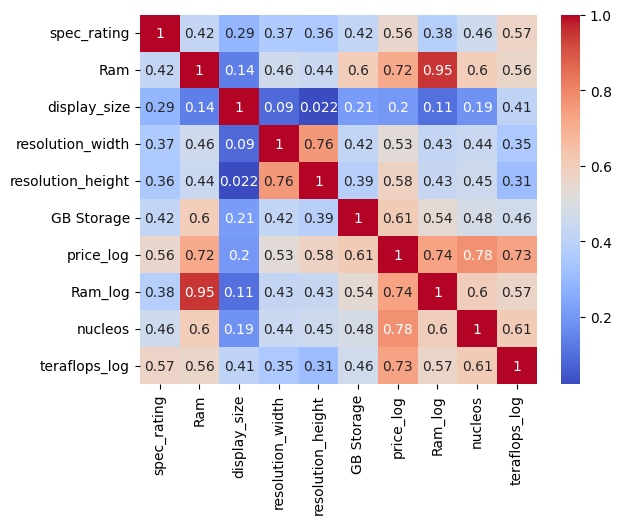

In [95]:
corra = df.corr(numeric_only=True)

sns.heatmap(corra, annot=True, cmap="coolwarm")

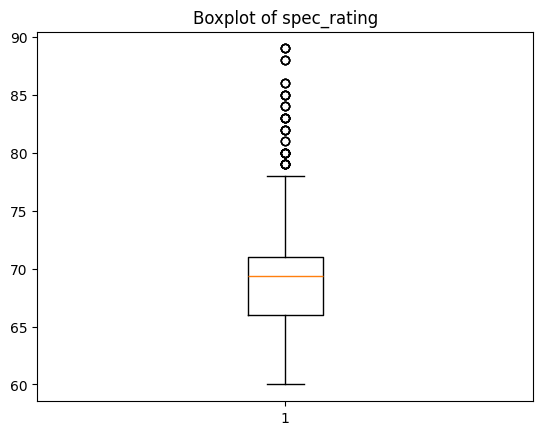

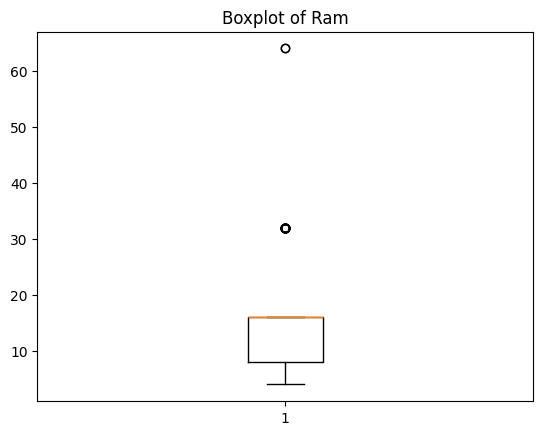

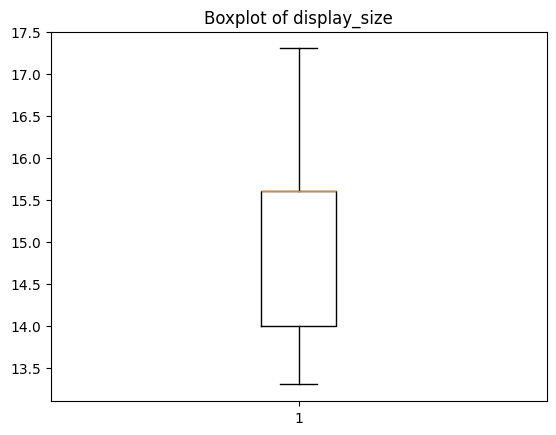

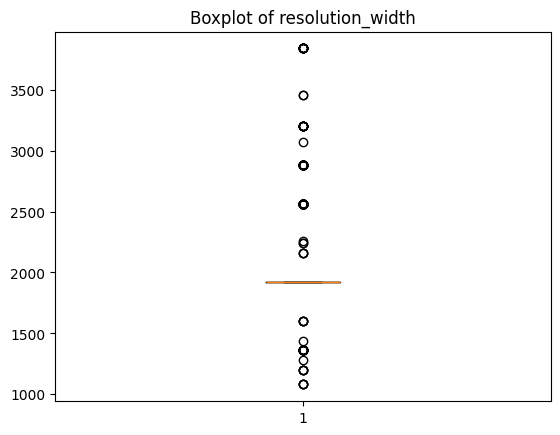

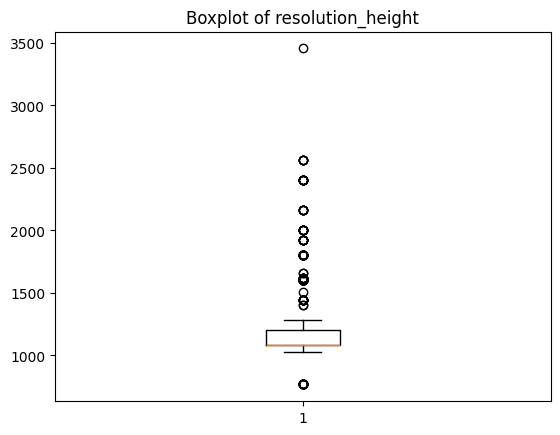

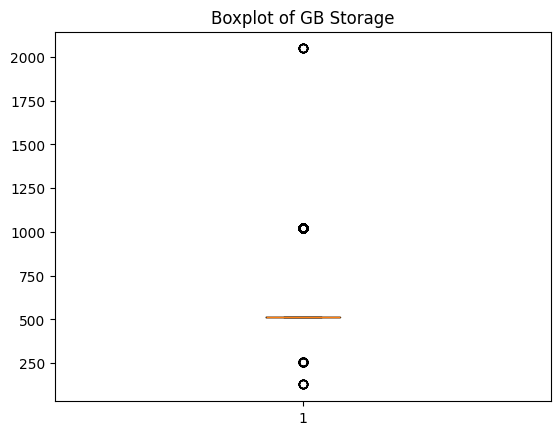

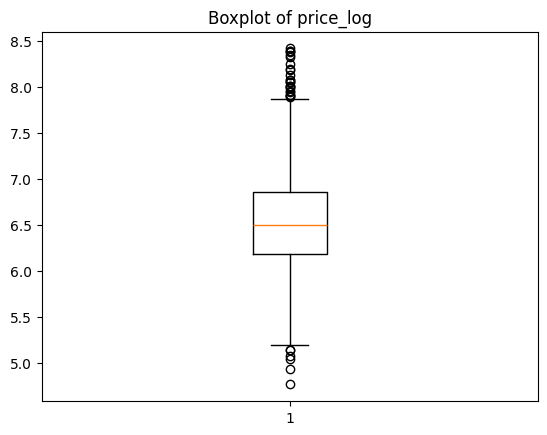

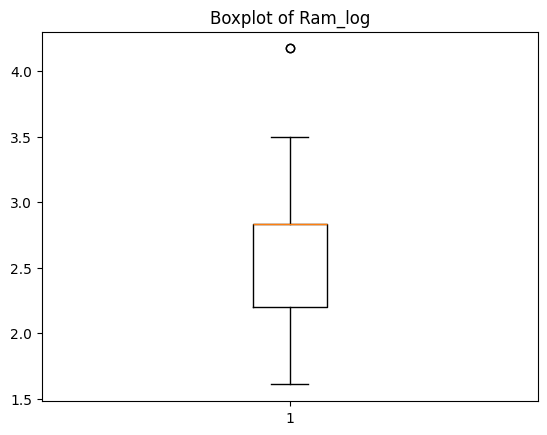

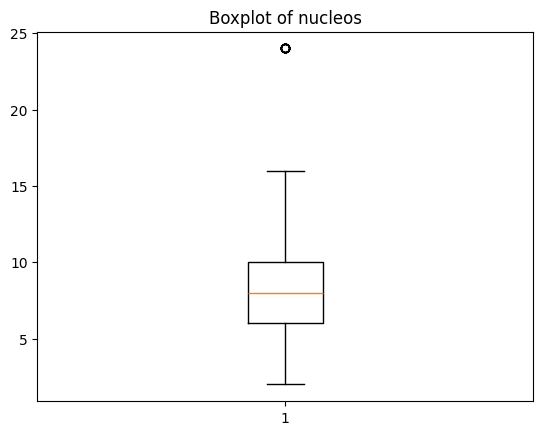

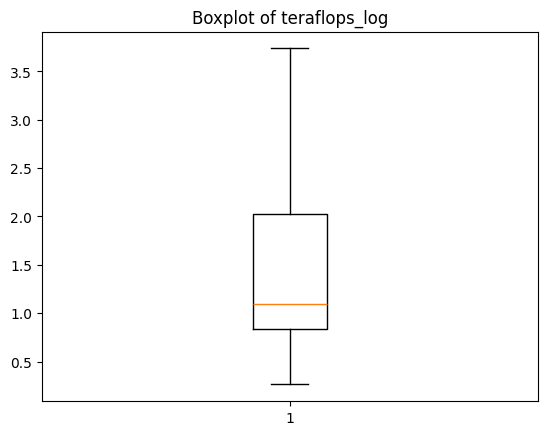

In [96]:
num_colsV4 = df.select_dtypes(include=['number']).columns

for col in num_colsV4:
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

**Resolución de pantalla → total de píxeles**

`resolution_width` y `resolution_height` están, por construcción, correlacionadas entre sí
(riesgo de multicolinealidad, sección 3) y ninguna de las dos por separado captura bien lo que
realmente importa para el precio: la cantidad total de píxeles. Se combinan en una sola variable:

In [97]:
df["total_pixeles"] = df["resolution_width"] * df["resolution_height"]
df["total_pixeles_log"] = np.log1p(df["total_pixeles"])

df = df.drop(columns=["resolution_width", "resolution_height", 'total_pixeles'])


In [98]:
df

,brand,spec_rating,Ram,Ram_type,ROM,ROM_type,display_size,OS,processor_brand,GB Storage,price_log,Ram_log,nucleos,gpu_brand,teraflops_log,total_pixeles_log
0,HP,73.000000,8,DDR4,512,SSD,15.6,Windows 11 OS,AMD,512,6.270224,2.197225,6.0,AMD,1.704748,14.544797
1,HP,60.000000,8,DDR4,512,SSD,15.6,Windows 11 OS,Intel,512,6.047053,2.197225,6.0,Intel,0.336472,14.544797
2,Acer,69.323529,8,DDR4,512,SSD,14.0,Windows 11 OS,Intel,512,5.657274,2.197225,2.0,Intel,1.098612,14.544797
3,Lenovo,66.000000,16,LPDDR5,512,SSD,14.0,Windows 11 OS,Intel,512,6.449709,2.833213,12.0,Intel,1.098612,14.958459
4,Acer,62.000000,8,DDR4,512,SSD,14.0,Windows 11 OS,Intel,512,6.049301,2.197225,12.0,Intel,1.098612,14.544797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
825,Acer,69.323529,16,LPDDR5,512,SSD,15.6,Windows 11 OS,Intel,512,6.402843,2.833213,10.0,Intel,1.098612,14.544797
826,Asus,69.323529,8,DDR4,512,SSD,15.6,Windows 11 OS,Intel,512,6.166850,2.197225,6.0,Intel,0.336472,14.544797
827,Asus,89.000000,32,DDR5,1024,SSD,14.0,Windows 11 OS,AMD,1024,7.605778,3.496508,8.0,Nvidia,2.533697,15.225522
828,Asus,73.000000,16,DDR4,512,SSD,15.6,Windows 11 OS,Intel,512,7.226494,2.833213,14.0,Nvidia,2.351375,14.544797


In [99]:
df['brand'].value_counts()

brand
HP             174
Lenovo         159
Asus           151
Other brand    102
Dell           101
Acer            78
MSI             65
Name: count, dtype: int64

## 12. Preparación final: eligiendo el conjunto de variables

Antes de modelar, se resuelven las últimas redundancias:

- `Ram_log` no aporta frente a `Ram` en escala original para este dataset, así que se conserva
  `Ram` (a diferencia de `price` y `teraflops`, donde sí se prefirió la versión logarítmica).
- `ROM` es redundante con `GB Storage` (ambas describen el almacenamiento; `GB Storage` ya es
  numérica y se extrajo de `ROM`), así que se descarta.

In [100]:
df.drop(['Ram_log'], axis = 1, inplace = True)

In [101]:
df['ROM'].value_counts()

ROM
512     603
1024    176
256      32
2048     10
128       9
Name: count, dtype: int64

<Axes: >

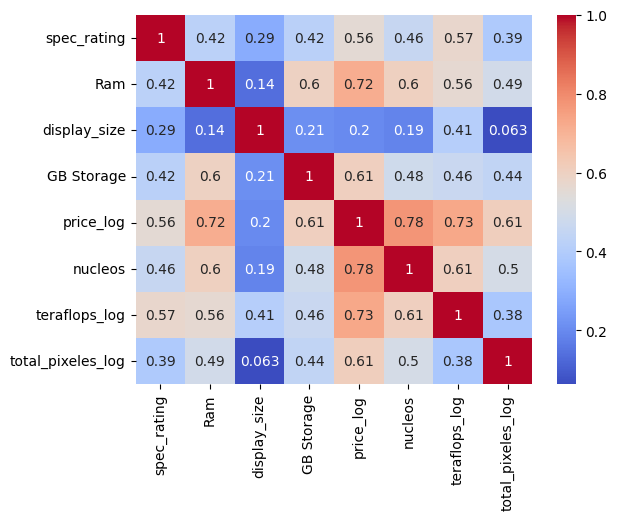

In [102]:
corra = df.corr(numeric_only=True)

sns.heatmap(corra, annot=True, cmap="coolwarm")

Se elimina definitivamente `ROM`, quedándonos con `GB Storage` como su equivalente numérico.

### Conjunto final de variables

| Tipo | Variables |
|---|---|
| Target | `price_log` |
| Numéricas | `display_size`, `Ram`, `GB Storage`, `nucleos`, `teraflops_log`, `total_pixeles_log` |
| Categóricas | `brand`, `Ram_type`, `OS`, `processor_brand`, `gpu_brand` |

In [103]:
df.drop(columns=['ROM'], inplace= True)

## 13. Reflexión: cómo se combinó conocimiento de computación y ciencia de datos

Antes de pasar al modelo, vale la pena nombrar explícitamente dónde entraron en juego, a la vez,
conocimiento de **computación/hardware** y de **ciencia de datos** — que es, en el fondo, el
valor que aporta este proyecto frente a simplemente "correr un `LinearRegression()`":

- **Parsing de texto técnico → variables numéricas.** Sin saber qué significa "Octa Core, 16
  Threads" o "4GB NVIDIA GeForce RTX 3050", no habría forma de decidir cómo extraer `nucleos` o
  `gpu_brand` de esas cadenas con expresiones regulares.
- **Conocimiento de especificaciones de hardware → una variable de rendimiento real.** El mapeo
  de más de 40 modelos de GPU a su rendimiento en TFLOPS convierte un identificador categórico (el
  nombre del modelo) en una medida continua y comparable de poder de cómputo.
- **Rigor estadístico → evitar *data leakage*.** Detectar y eliminar la variable de "gama de
  procesador" basada en el precio promedio histórico (sección 6) es una decisión de ciencia de
  datos: un modelo evaluado con una variable "contaminada" por la respuesta se ve artificialmente
  preciso y falla en producción. Esa misma disciplina se repite más adelante, en la sección de
  modelado, al separar entrenamiento y prueba **antes** de escalar y de codificar variables — así
  ninguna estadística de la prueba se filtra al entrenamiento.
- **Supuestos del modelo → decisiones de transformación.** Aplicar `log1p` a `price` y
  `teraflops`, o combinar resolución en `total_pixeles`, responden directamente a los cuatro
  supuestos de la regresión lineal de la sección 3.

El resultado buscado es un modelo que no solo prediga bien, sino que sea **defendible**: cada
variable que entra al modelo tiene una razón técnica y estadística documentada para estar ahí.

## 14. Preparando el dataset para el modelo

Se revisa el estado final del dataframe y se separan variables predictoras (`X`) de la variable
respuesta (`y = price_log`). Nótese que, en este punto, `X` todavía contiene las columnas
categóricas como texto (`brand`, `Ram_type`, `OS`, `processor_brand`, `gpu_brand`): la
codificación a variables dummy se hace más adelante, **después** de dividir en train/test, para
que no haya fuga de información entre ambos conjuntos.

In [104]:
df.info()

X = df.drop('price_log', axis= 1)
y = df['price_log']

<class 'pandas.DataFrame'>
RangeIndex: 830 entries, 0 to 829
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              830 non-null    str    
 1   spec_rating        830 non-null    float64
 2   Ram                830 non-null    int64  
 3   Ram_type           830 non-null    str    
 4   ROM_type           830 non-null    str    
 5   display_size       830 non-null    float64
 6   OS                 830 non-null    str    
 7   processor_brand    830 non-null    str    
 8   GB Storage         830 non-null    int64  
 9   price_log          830 non-null    float64
 10  nucleos            830 non-null    float64
 11  gpu_brand          830 non-null    str    
 12  teraflops_log      830 non-null    float64
 13  total_pixeles_log  830 non-null    float64
dtypes: float64(6), int64(2), str(6)
memory usage: 90.9 KB


## 15. División en entrenamiento y prueba

Se separa 70% de las observaciones para entrenar el modelo y 30% para evaluarlo con datos que no
vio durante el entrenamiento (`test_size=0.3`). Esta división se hace **antes** de escalar y
codificar variables — una decisión correcta y deliberada: si se escalara o codificara sobre todo
el dataset antes de dividir, estadísticas del conjunto de prueba (medias, desviaciones, categorías
presentes) se filtrarían al entrenamiento.

In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 45)

## 16. Escalado de variables numéricas

`StandardScaler` reescala cada variable numérica para que tenga media 0 y desviación estándar 1.
Para una regresión lineal esto no cambia la calidad de las predicciones, pero sí cambia cómo se
interpretan los coeficientes (más adelante, cada coeficiente numérico representa el efecto de un
cambio de **una desviación estándar**, no de "una unidad").

El detalle importante — y que la celda respeta correctamente — es que el escalador se **ajusta
(`fit_transform`) solo con los datos de entrenamiento** y luego se **aplica (`transform`) al
conjunto de prueba** con esos mismos parámetros. Ajustarlo con todo el dataset sería, otra vez,
una forma de *data leakage*: el modelo "vería" indirectamente la distribución del conjunto de
prueba antes de ser evaluado en él.

In [106]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_colsV5 = X_train.select_dtypes(include=[np.number]).columns.tolist()

X_train[num_colsV5] = scaler.fit_transform(X_train[num_colsV5])
X_test[num_colsV5] = scaler.transform(X_test[num_colsV5])


## 17. Codificación de variables categóricas

Igual que con el escalado, el one-hot encoding (`pd.get_dummies`, con `drop_first=True` para
evitar multicolinealidad perfecta entre dummies) se aplica por separado a `X_train` y `X_test`, y
luego se **alinean** las columnas de ambos conjuntos (`X_train.align(X_test, ...)`). Esto es
necesario porque, si alguna categoría rara aparece solo en uno de los dos conjuntos tras la
partición aleatoria, `get_dummies` generaría un número distinto de columnas en cada uno; `align`
con `fill_value=0` asegura que ambos terminen con exactamente las mismas columnas.

> **Detalle menor visto en tu salida real:** pandas muestra un `Pandas4Warning` al usar
> `select_dtypes(include=['object'])`, avisando que en próximas versiones de pandas el dtype
> `'str'` dejará de incluirse automáticamente bajo `'object'`. No afecta el resultado actual, pero
> si actualizas pandas más adelante quizás convenga usar `include=['object', 'str']` explícito.

In [107]:
cats_colV3 = X_train.select_dtypes(include=['object']).columns.tolist()
#Tener en cuenta primero entrenar el modelo, dos variables scalares fit)_transform a train y transform a test esto dando a diferenciar
#Que se necesita hacer la propia diferencia para estos y no crear data leakege donde el modelo tendria acceso a informacion a cosas que estarian en fase de entrenamiento

X_train = pd.get_dummies(X_train ,columns= cats_colV3, drop_first= True)
X_test = pd.get_dummies(X_test ,columns= cats_colV3, drop_first= True)

#Las dummies por igual entrenarlas y sobre todo hacer el align de manera efectiva.
#Ya que podria pasar que estost no se conviertan datos que aparecerian entre test y split.
#Por lo tanto alinearlos es la manera mas efectiva de conseguir una mejor efectividad

X_train, X_test = X_train.align(X_test, join='left', axis=1 , fill_value=0)

C:\Users\Diego Monegro\AppData\Local\Temp\ipykernel_14900\3283387382.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cats_colV3 = X_train.select_dtypes(include=['object']).columns.tolist()


## 18. Entrenamiento y evaluación: Regresión Lineal

Se entrena el modelo sobre `price_log` y las predicciones se revierten a la escala real de precio
(`np.expm1`) antes de calcular las métricas — así MAE, RMSE y MAPE quedan en dólares (o
porcentaje), directamente interpretables para alguien sin formación técnica.

In [108]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt

# Entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predicciones en escala log (la escala del target)
y_pred_log = modelo.predict(X_test)

# Revertir a escala real de precio para que las métricas sean interpretables
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

# Métricas
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mape = mean_absolute_percentage_error(y_test_real, y_pred_real) * 100

print("=== Métricas del modelo (escala real de precio) ===")
print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")


=== Métricas del modelo (escala real de precio) ===
MAE:  180.39
RMSE: 394.64
MAPE: 18.14%


**Resultado real obtenido (con tu dataset, 830 laptops tras la limpieza):**

| Métrica | Valor |
|---|---|
| MAE | \$180.39 |
| RMSE | \$394.64 |
| MAPE | 18.14% |

En criollo: en promedio, el modelo se equivoca por unos \$180 al predecir el precio de una laptop
que no vio durante el entrenamiento, con un error porcentual típico de ~18%.

Diagnóstico visual: comparar cada predicción contra el valor real. Cuanto más cerca estén los
puntos de la línea roja (predicción perfecta), mejor.

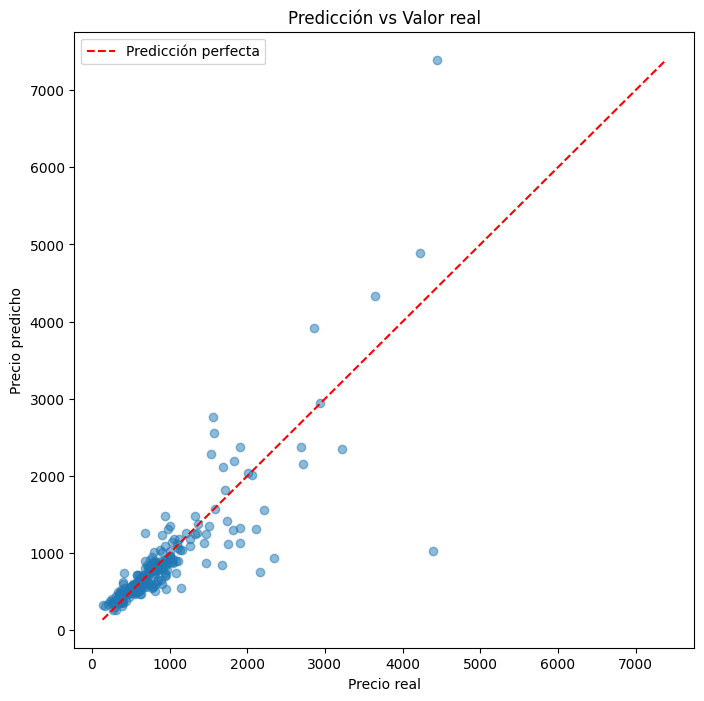

In [109]:
# Gráfica: valor real vs predicho, con la línea de predicción perfecta (y = x)
plt.figure(figsize=(8, 8))
plt.scatter(y_test_real, y_pred_real, alpha=0.5)

min_val = min(y_test_real.min(), y_pred_real.min())
max_val = max(y_test_real.max(), y_pred_real.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Predicción perfecta')

plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Predicción vs Valor real')
plt.legend()
plt.show()


### Interpretación de coeficientes

> **Nota:** esta celda asume que ya existe un DataFrame `coeficientes` con las columnas
> `variable` y `coeficiente`. No hay ninguna celda anterior en este archivo que lo cree — a juzgar
> por los números de ejecución (`In [110]` → `In [113]`), probablemente había una o dos celdas
> intermedias que se ejecutaron y luego se borraron antes de guardar. El resultado de abajo es
> real (quedó guardado de esa ejecución), pero si corres el notebook de nuevo de corrido vas a
> necesitar recrear esa celda, algo como:
> `coeficientes = pd.DataFrame({"variable": X_train.columns, "coeficiente": modelo.coef_})`.

Como las variables numéricas fueron escaladas (`StandardScaler`) y el target está en escala
logarítmica, `efecto_%` (calculado como `(exp(coeficiente) - 1) * 100`) se interpreta distinto
según el tipo de variable: para una variable numérica, es el cambio porcentual esperado en el
precio ante un aumento de **una desviación estándar**; para una variable dummy, es el cambio
porcentual frente a la categoría de referencia.

**Lectura de tu resultado real:** las variables con mayor efecto positivo son sobre todo de
**marca** (`brand_Dell` +30%, `brand_HP` +27%, `brand_Lenovo` +22%) y `gpu_brand_Nvidia` (+24%),
seguidas de especificaciones técnicas (`nucleos` +18%, `teraflops_log` +14%). Un hallazgo curioso:
`processor_brand_Intel` sale levemente negativo (-3.8%) frente a AMD (la categoría de referencia)
y `display_size` también (-4.0%) — con todo lo demás constante, tener procesador Intel o una
pantalla más grande no está empujando el precio hacia arriba en este dataset. Esto no
necesariamente significa que "Intel abarata la laptop": puede reflejar que, en este dataset, las
laptops Intel/con pantallas grandes tienden a compensarse con otras variables ya incluidas en el
modelo (correlación, no causalidad).

In [113]:
coeficientes = pd.DataFrame({
    'variable': X_train.columns,
    'coeficiente': modelo.coef_
})

coeficientes['abs_coef'] = coeficientes['coeficiente'].abs()
coeficientes = coeficientes.sort_values('abs_coef', ascending=False).drop(columns='abs_coef')

print(coeficientes.to_string(index=False))


             variable  coeficiente
           brand_Dell     0.265579
             brand_HP     0.240565
     gpu_brand_Nvidia     0.213320
         brand_Lenovo     0.198504
         ROM_type_SSD     0.179180
              nucleos     0.169533
     OS_Windows 10 OS     0.153291
    brand_Other brand     0.140087
        teraflops_log     0.134751
           brand_Asus     0.131887
      Ram_type_LPDDR5     0.121450
      gpu_brand_Intel     0.120654
                  Ram     0.113222
            brand_MSI     0.095670
    total_pixeles_log     0.086333
        Ram_type_DDR5     0.075928
           GB Storage     0.063349
      Ram_type_LPDDR4     0.062843
         display_size    -0.040357
processor_brand_Intel    -0.038781
          spec_rating     0.034803
     OS_Windows 11 OS    -0.021767


Visualizando el mismo resultado como gráfico de barras, ordenado por magnitud del coeficiente:

El cual este tiene ciertas fricciones

De verdad las marcas Dell y HP es la mas influyentes a la hora de precio?

La RAM , gafrica y specs llaman menos a un modelo a que el precio sea mas caro.

Estos son supuestos los cuales te das cuenta, que el modelo no interpreta tanto la realidad
como uno de verdad entendenria

Por lo tanto debemos buscar mas informacion o en Data Science mejores modelos


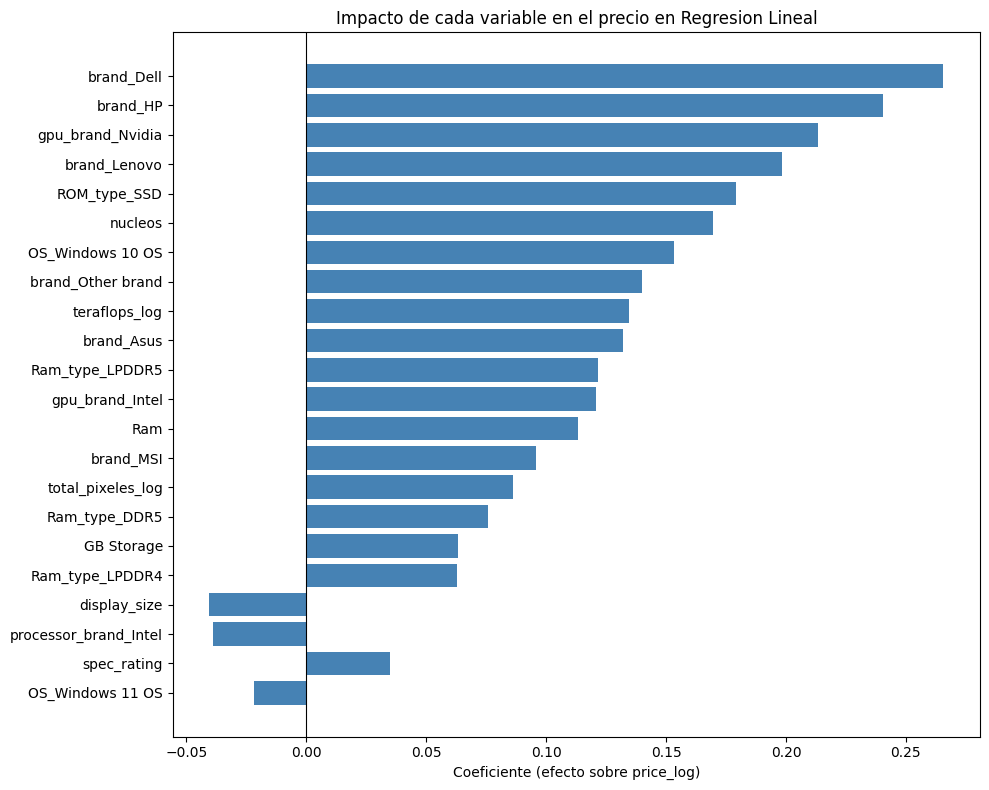

In [114]:
plt.figure(figsize=(10, 8))
plt.barh(coeficientes['variable'], coeficientes['coeficiente'], color='steelblue')
plt.xlabel('Coeficiente (efecto sobre price_log)')
plt.title('Impacto de cada variable en el precio en Regresion Lineal')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 19. ¿Vale la pena sacrificar interpretabilidad por precisión?

La regresión lineal es interpretable, pero asume relaciones lineales entre las variables (en la
escala transformada) y no captura interacciones entre ellas (p. ej. "la RAM alta solo eleva el
precio si la GPU también es potente"). Para cuantificar qué tanto se pierde en precisión al elegir
un modelo interpretable, se entrena el mismo conjunto de datos con dos modelos de conjunto
("ensemble") mucho más flexibles — Random Forest y XGBoost — y se comparan las tres métricas
(MAE, RMSE, MAPE) en la misma escala real de precio.

In [112]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

resultados = {}

def evaluar_modelo(nombre, modelo):
    modelo.fit(X_train, y_train)
    y_pred_log = modelo.predict(X_test)

    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    mape = mean_absolute_percentage_error(y_test_real, y_pred_real) * 100

    resultados[nombre] = {'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}

    print(f"=== {nombre} ===")
    print(f"MAE:  ${mae:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"MAPE: {mape:.2f}%\n")

    return modelo

modelo_lr  = evaluar_modelo("Regresión Lineal", LinearRegression())
modelo_rf  = evaluar_modelo("Random Forest", RandomForestRegressor(n_estimators=300, random_state=45))
modelo_xgb = evaluar_modelo("XGBoost", XGBRegressor(n_estimators=300, random_state=45))


=== Regresión Lineal ===
MAE:  $180.39
RMSE: $394.64
MAPE: 18.14%

=== Random Forest ===
MAE:  $157.60
RMSE: $349.84
MAPE: 15.33%

=== XGBoost ===
MAE:  $160.09
RMSE: $353.94
MAPE: 16.22%



Se ordena la comparación por RMSE (el modelo con menor error típico, penalizando más los errores
grandes) para identificar el mejor candidato:

**Resultado real obtenido:**

| Modelo | MAE | RMSE | MAPE |
|---|---|---|---|
| Random Forest | \$157.60 | \$349.84 | 15.33% |
| XGBoost | \$160.09 | \$353.94 | 16.22% |
| Regresión Lineal | \$180.39 | \$394.64 | 18.14% |

Antes de afinar hiperparámetros, **Random Forest** queda primero: ~11% menos de RMSE que la
regresión lineal. Es un resultado razonable — confirma que sí hay algo de no-linealidad o
interacción entre variables que un modelo de árboles puede aprovechar, aunque la diferencia no es
enorme, lo que sugiere que la regresión lineal (con todo el trabajo de limpieza y transformación
de este notebook) no está lejos del techo de lo que estas variables pueden explicar.

In [ ]:
comparacion = pd.DataFrame(resultados).T.sort_values('RMSE')
print(comparacion)

mejor_modelo = comparacion.index[0]
print(f"\nMejor modelo según RMSE: {mejor_modelo}")


                         MAE        RMSE   MAPE (%)
Random Forest     157.599330  349.841669  15.326624
XGBoost           160.093027  353.941638  16.218735
Regresión Lineal  180.393407  394.636660  18.135215

Mejor modelo según RMSE: Random Forest


Y se visualiza para comparar de un vistazo:

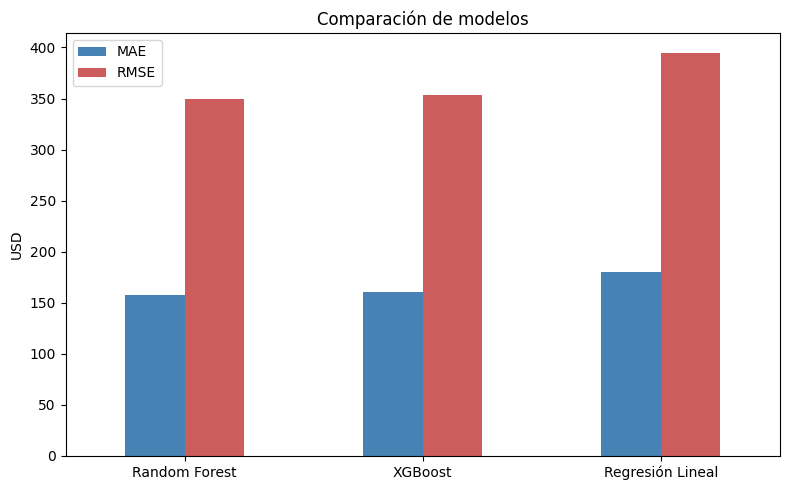

In [ ]:
comparacion[['MAE', 'RMSE']].plot(kind='bar', figsize=(8, 5), color=['steelblue', 'indianred'])
plt.ylabel('USD')
plt.title('Comparación de modelos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 20. Afinando hiperparámetros del mejor candidato (XGBoost)

`GridSearchCV` prueba sistemáticamente combinaciones de hiperparámetros (número de árboles,
profundidad, tasa de aprendizaje, submuestreo de filas y columnas) con validación cruzada de 5
particiones (`cv=5`), en vez de confiar en una sola división train/test.

Un detalle importante: el `scorer` personalizado (`rmse_real`) revierte las predicciones a dólares
reales con `np.expm1` **antes** de calcular el RMSE. Esto asegura que la búsqueda de
hiperparámetros optimice el error que realmente le importa al negocio (dólares), y no un proxy en
escala logarítmica que podría no coincidir con el mejor modelo en términos de dólares.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

def rmse_real(y_true_log, y_pred_log):
    y_true_real = np.expm1(y_true_log)
    y_pred_real = np.expm1(y_pred_log)
    return np.sqrt(mean_squared_error(y_true_real, y_pred_real))

rmse_scorer = make_scorer(rmse_real, greater_is_better=False)

param_grid_xgb = {
    'n_estimators': [200, 400, 600],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    estimator=XGBRegressor(random_state=45),
    param_grid=param_grid_xgb,
    scoring=rmse_scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_xgb.best_params_)
print(f"Mejor RMSE (CV, en USD): ${-grid_xgb.best_score_:,.2f}")


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejores hiperparámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 600, 'subsample': 0.8}
Mejor RMSE (CV, en USD): $247.58


**Resultado real obtenido:** `GridSearchCV` probó 108 combinaciones × 5 particiones = 540 ajustes
de XGBoost, y encontró como mejores hiperparámetros `n_estimators=600`, `max_depth=3`,
`learning_rate=0.05`, `subsample=0.8`, `colsample_bytree=0.8`, con un RMSE de validación cruzada
de **\$247.58** (en dólares reales). Nótese que este número no es directamente comparable con el
RMSE de \$349–395 de la sección anterior: aquí se promedia sobre 5 particiones de
entrenamiento/validación distintas, mientras que el de la sección 19 viene de un único conjunto de
prueba fijo — la comparación justa es la que se hace en la celda siguiente, evaluando el modelo
afinado sobre ese mismo conjunto de prueba.

Se evalúa el modelo ya afinado, sobre el mismo conjunto de prueba usado para los demás modelos, y se actualiza la tabla comparativa:

In [ ]:
modelo_xgb_tuned = evaluar_modelo("XGBoost (tuned)", grid_xgb.best_estimator_)

comparacion = pd.DataFrame(resultados).T.sort_values('RMSE')
print(comparacion)


=== XGBoost (tuned) ===
MAE:  $156.02
RMSE: $348.49
MAPE: 14.53%

                         MAE        RMSE   MAPE (%)
XGBoost (tuned)   156.016893  348.487172  14.528844
Random Forest     157.599330  349.841669  15.326624
XGBoost           160.093027  353.941638  16.218735
Regresión Lineal  180.393407  394.636660  18.135215


**Resultado real obtenido:** con el afinado, XGBoost pasa a ser el mejor modelo de los cuatro
(MAE \$156.02, RMSE \$348.49, MAPE 14.53%) — apenas por delante de Random Forest sin afinar
(RMSE \$349.84). La ganancia de la búsqueda de hiperparámetros existe pero es modesta (~0.4% menos
de RMSE que Random Forest, ~11.7% menos que la regresión lineal), lo que en este dataset sugiere
que ya se estaba cerca del límite de lo que estas variables predictoras pueden explicar del
precio, más que de un problema de mal ajuste del modelo.

Diagnóstico visual del modelo afinado, igual que se hizo antes con la regresión lineal:

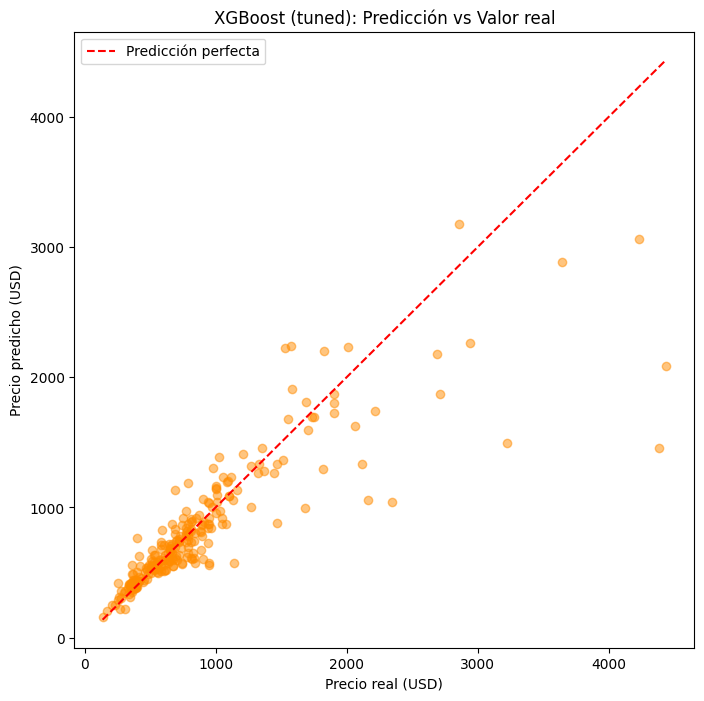

In [ ]:
y_pred_log_tuned = grid_xgb.best_estimator_.predict(X_test)
y_pred_tuned_real = np.expm1(y_pred_log_tuned)
y_test_real = np.expm1(y_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test_real, y_pred_tuned_real, alpha=0.5, color='darkorange')

min_val = min(y_test_real.min(), y_pred_tuned_real.min())
max_val = max(y_test_real.max(), y_pred_tuned_real.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Predicción perfecta')

plt.xlabel('Precio real (USD)')
plt.ylabel('Precio predicho (USD)')
plt.title('XGBoost (tuned): Predicción vs Valor real')
plt.legend()
plt.show()


### Importancia de variables (XGBoost)

A diferencia de los coeficientes de la regresión lineal (que tienen signo y magnitud
interpretable), la importancia de variables de XGBoost mide cuánto contribuye cada variable a
reducir el error dentro de los árboles, **sin indicar dirección**: una variable puede ser muy
importante sin que se sepa, con solo mirar este gráfico, si empuja el precio hacia arriba o hacia
abajo. Comparar esta lista contra los coeficientes de la sección 18 es una buena forma de detectar
si ambos modelos "están de acuerdo" en qué variables importan más.

             variable  importancia
              nucleos     0.213701
                  Ram     0.194354
        teraflops_log     0.149459
    total_pixeles_log     0.078666
     gpu_brand_Nvidia     0.073507
           GB Storage     0.039026
          spec_rating     0.031473
      Ram_type_LPDDR5     0.030396
           brand_Dell     0.023014
         display_size     0.020917
     OS_Windows 11 OS     0.020481
     OS_Windows 10 OS     0.020141
        Ram_type_DDR5     0.015227
processor_brand_Intel     0.015009
    brand_Other brand     0.013125
             brand_HP     0.011904
      gpu_brand_Intel     0.010276
            brand_MSI     0.009629
         brand_Lenovo     0.008825
      Ram_type_LPDDR4     0.008149
           brand_Asus     0.007529
         ROM_type_SSD     0.005191


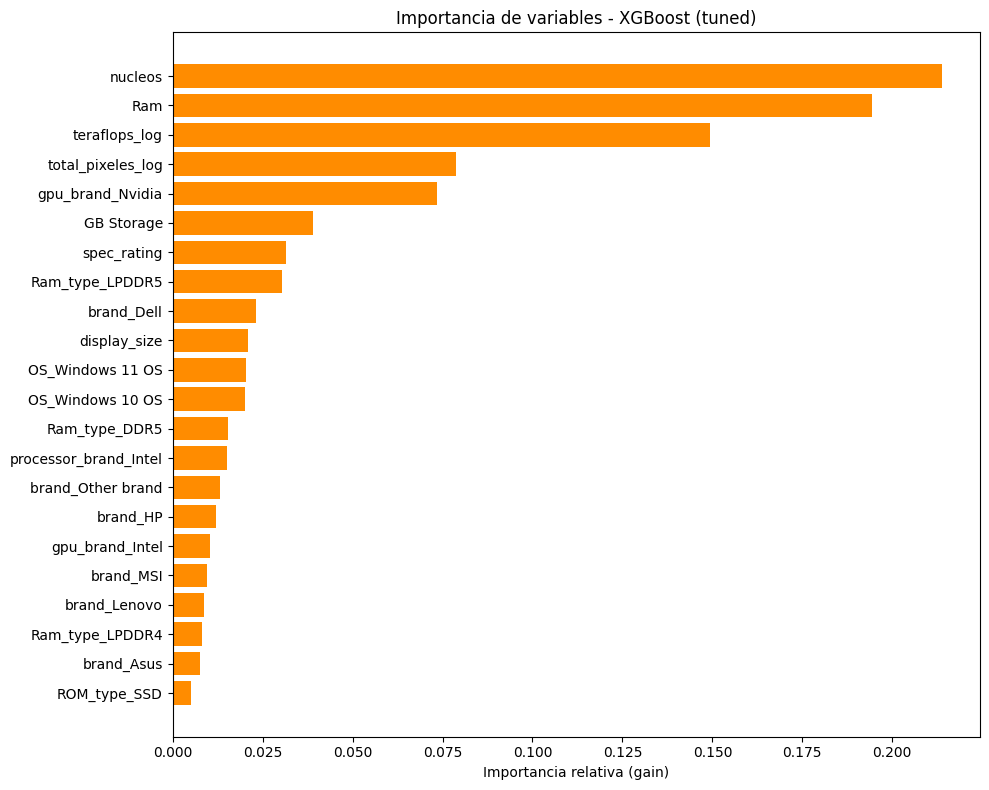

In [ ]:
importancias = pd.DataFrame({
    'variable': X_train.columns,
    'importancia': grid_xgb.best_estimator_.feature_importances_
}).sort_values('importancia', ascending=False)

print(importancias.to_string(index=False))

plt.figure(figsize=(10, 8))
plt.barh(importancias['variable'], importancias['importancia'], color='darkorange')
plt.xlabel('Importancia relativa (gain)')
plt.title('Importancia de variables - XGBoost (tuned)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Resultado real obtenido — y un contraste interesante con la regresión lineal:** para XGBoost,
las variables más importantes son `nucleos` (0.21), `Ram` (0.19), `teraflops_log` (0.15) y
`total_pixeles_log` (0.08) — puras especificaciones técnicas. La regresión lineal, en cambio, daba
más peso a la **marca** (`brand_Dell`, `brand_HP`, `brand_Lenovo`) que a estas mismas
especificaciones. Ambos modelos sí coinciden en que `gpu_brand_Nvidia` importa bastante.

Una lectura posible: la marca probablemente actúa como una especie de "proxy" de calidad/segmento
que la regresión lineal aprovecha porque no puede modelar interacciones (p. ej. "Lenovo tiende a
combinar ciertas specs de forma consistente"), mientras que XGBoost, al poder combinar variables
de forma no lineal, encuentra más señal directamente en las especificaciones técnicas y le da
menos peso extra a la marca en sí. Es exactamente el tipo de patrón que vale la pena explorar con
SHAP values como siguiente paso (sección 21).

## 21. Conclusiones y próximos pasos

**Resumen del proceso.** Partiendo de un dataset crudo de especificaciones de laptops en el
mercado indio (830 laptops tras la limpieza), se construyó un pipeline completo de limpieza,
ingeniería de variables (con énfasis en traducir conocimiento de hardware a variables numéricas),
un modelo interpretable de regresión lineal, y una comparación sistemática contra modelos más
flexibles (Random Forest, XGBoost) con afinado de hiperparámetros vía validación cruzada.

**Resultados obtenidos (en el conjunto de prueba, en dólares reales):**

| Modelo | MAE | RMSE | MAPE |
|---|---|---|---|
| XGBoost (afinado con GridSearchCV) | \$156.02 | \$348.49 | 14.53% |
| Random Forest | \$157.60 | \$349.84 | 15.33% |
| XGBoost (sin afinar) | \$160.09 | \$353.94 | 16.22% |
| Regresión Lineal | \$180.39 | \$394.64 | 18.14% |

El modelo interpretable (regresión lineal) predice con un error típico de ~\$180 (MAPE ~18%).
Pasar a un modelo de árboles reduce el RMSE en un 11-12%, y afinar hiperparámetros con
`GridSearchCV` aporta una mejora adicional pequeña. Es un resultado honesto: hay margen de mejora
con modelos más flexibles, pero no es una diferencia abismal — buena parte de la señal
predictiva ya la captura la regresión lineal con las variables e ingeniería de este notebook.

**Lo que dicen las variables:** la regresión lineal encuentra que la **marca** (Dell, HP, Lenovo)
y tener GPU Nvidia son los factores con mayor efecto positivo sobre el precio, mientras que
XGBoost prioriza especificaciones técnicas puras (núcleos, RAM, TFLOPS de GPU). Ambos coinciden en
el peso de la GPU Nvidia. Esta discrepancia entre "qué explica el precio" según cada modelo es en
sí misma un hallazgo interesante del proyecto (ver sección 20).

**Decisiones clave que sostienen la validez del proceso:**
- Eliminación de una variable con *data leakage* (gama de procesador basada en precio histórico).
- División train/test **antes** de escalar y codificar variables, para que ninguna estadística del
  conjunto de prueba se filtre al entrenamiento.
- Transformaciones logarítmicas alineadas con los supuestos de linealidad, homocedasticidad y
  no-multicolinealidad de la regresión lineal.
- Optimización de hiperparámetros usando como métrica el error en dólares reales, no un proxy en
  escala logarítmica.

**Limitaciones a tener en cuenta:**
- El dataset proviene del mercado indio (precios originales en INR); el modelo puede no
  generalizar directamente a otros mercados sin recalibrar.


